In [619]:
#df = pd.read_csv("../2026-02-QD_edited.csv")
macro_fred_df = pd.read_csv("../2026-02-MD_edited.csv")
cc_risk_df = pd.read_csv("../credit_risk_dataset.csv")

###### Imports (collapse)

In [2]:
# OS
import os

# pythonic handling
import pandas as pd
import numpy as np
from tqdm import tqdm

# visuals
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# models, datasets
import sklearn
import kagglehub
from sklearn import decomposition, linear_model, metrics


from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, LeaveOneOut
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/home/codespace/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
'''!pip install statsmodels
!pip install openpyxl'''

In [623]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import mstats
from scipy.stats import randint, uniform
#from fredmd_transform import transform_fredmd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# Milestone 4 Notebook

## Functions Sections

### Argument to be made ... (micro dataset to macro time series dataset)

* If interest rate is a top predictor of default → macro equivalent is FEDFUNDS, GS10, or TB3MS (rate environment drives affordability stress)
*  If income is a top predictor → macro equivalent is RPI, PAYEMS, or W875RX1 (aggregate income/employment conditions)
*  If home ownership matters → macro equivalent is HOUST, PERMIT (housing market conditions) or REALLN (real estate lending)
*  If previous default flag matters → macro equivalent is BUSLOANS, NONREVSL, DTCTHFNM (aggregate credit stress indicators)
* If loan-to-income ratio matters → macro equivalent is CONSPI (consumer credit to personal income ratio — this one is actually a direct analog)

The analysis made in the micro econ dataset inform target variable selection in the macro econ dataset. This is a *bottoms-up* argument.

Things to consider:
* Direction of causality — your cross-sectional model shows correlation, not causation. A reviewer might push back that macro conditions cause the micro factors, not the other way around. You'd want to frame it as "these micro factors are the transmission channel through which macro conditions affect default risk"
* Variable selection method matters — if you use something interpretable like logistic regression with coefficients, or SHAP values from a tree model, your argument is much cleaner than just saying "this variable ranked highly"
* CONSPI deserves special attention — it's literally the ratio of nonrevolving consumer credit to personal income, which is almost a direct macro translation of your loan-to-income ratio feature. That's probably your strongest single bridge between the two datasets

### **Week 1-7**
***

#### 🔢 Univariate Functions

##### Week 1

###### df.describe()

In [ ]:
# Week 1
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe()

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
25%,1.750000,4.750000
50%,2.500000,5.500000
75%,3.250000,6.250000
max,4.000000,7.000000


##### Week 2

###### df.info()

In [7]:
# Week 2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       4 non-null      int64
 1   B       4 non-null      int64
dtypes: int64(2)
memory usage: 196.0 bytes


##### Week 3

###### Histogram

<Axes: ylabel='Count'>

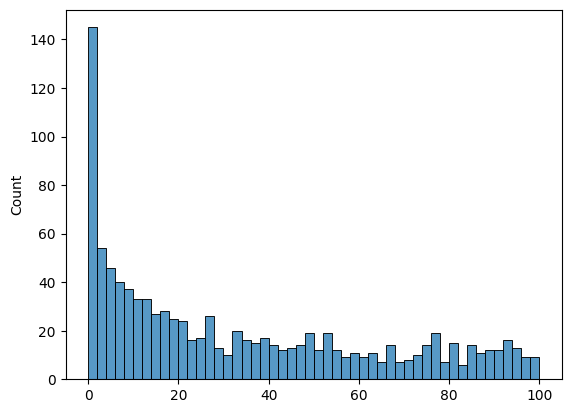

In [14]:
# Week 3
## create random array for visual
np.random.seed(0)
lesson_series = np.round(np.random.random(size = 1000)**2 * 100, 2)
lesson_series[0:10]
## plot histogram (with bins parameters)
sns.histplot(lesson_series, bins = 50)

###### KDE

<Axes: ylabel='Density'>

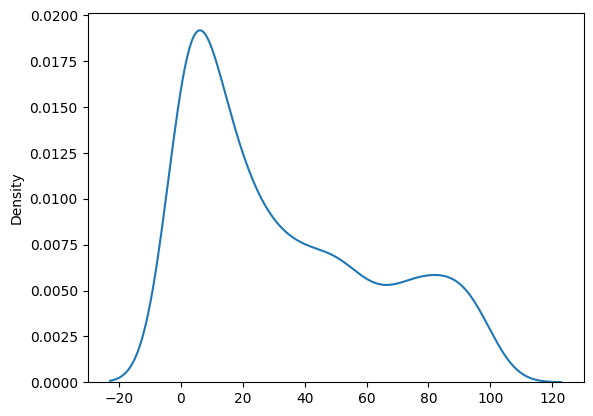

In [ ]:
# Week 3
## Kernel Density Estimate
sns.kdeplot(lesson_series)

###### Boxplot

<Axes: >

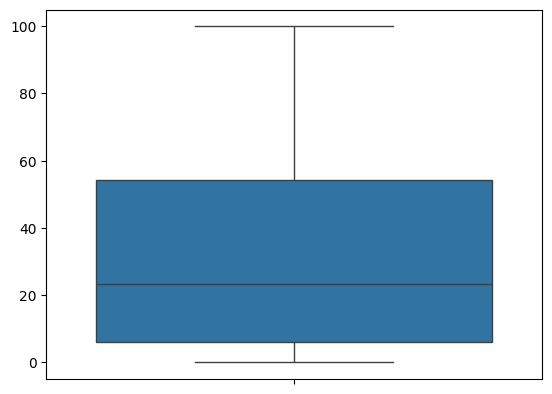

In [19]:
# Week 3
## Boxplot
sns.boxplot(lesson_series)

###### Violinplot

<Axes: >

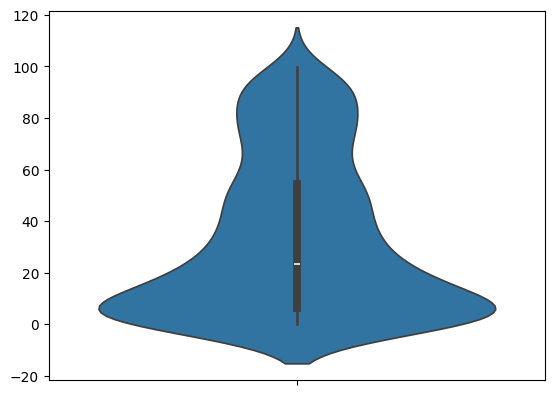

In [20]:
# Week 3
## Violinplot
sns.violinplot(lesson_series)

###### Swarmplot

<Axes: >

/home/codespace/.local/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


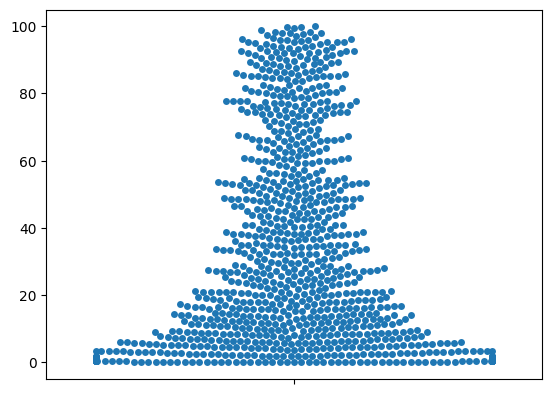

In [21]:
# Week 3
## Swarm plot (like violin but every point shown)
sns.swarmplot(lesson_series)

##### Week 4

###### Histogram again

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

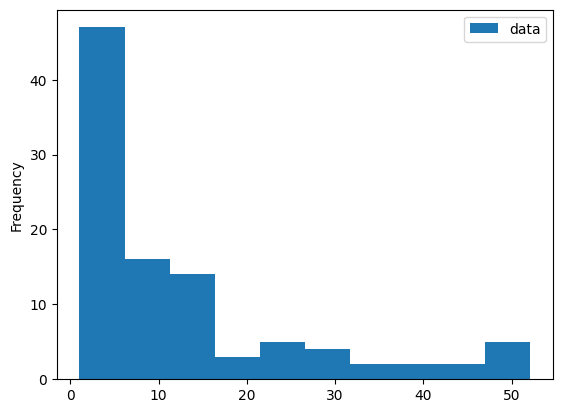

In [22]:
# Week 4
## intialize new df
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])
## get 75 quantile & make histogram plot
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

###### Boxplot ... again

<Axes: >

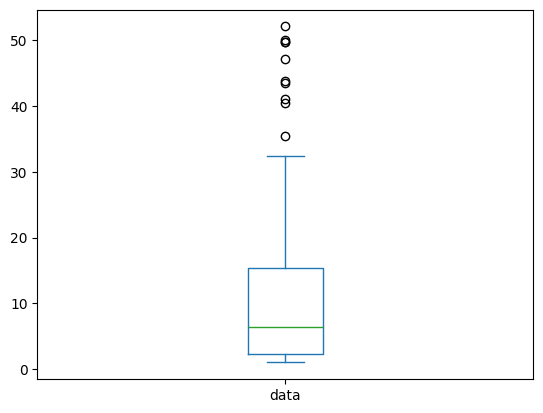

In [23]:
# Week 4
df.plot.box()

#### 🔢 Bivariate Functions

##### Week 5

###### sns Scatterplot

<Axes: >

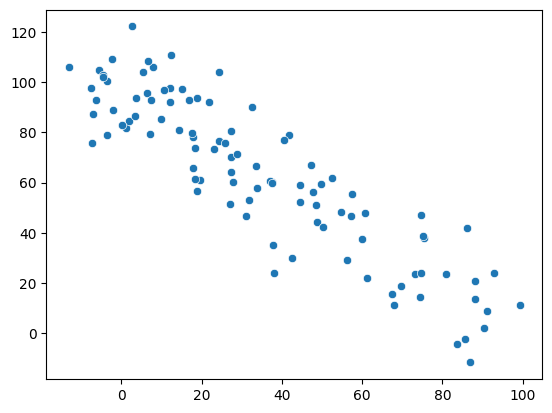

In [6]:
# Week 5
## initialize a set of series
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)
## scatterplot
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

###### sns Pairplot

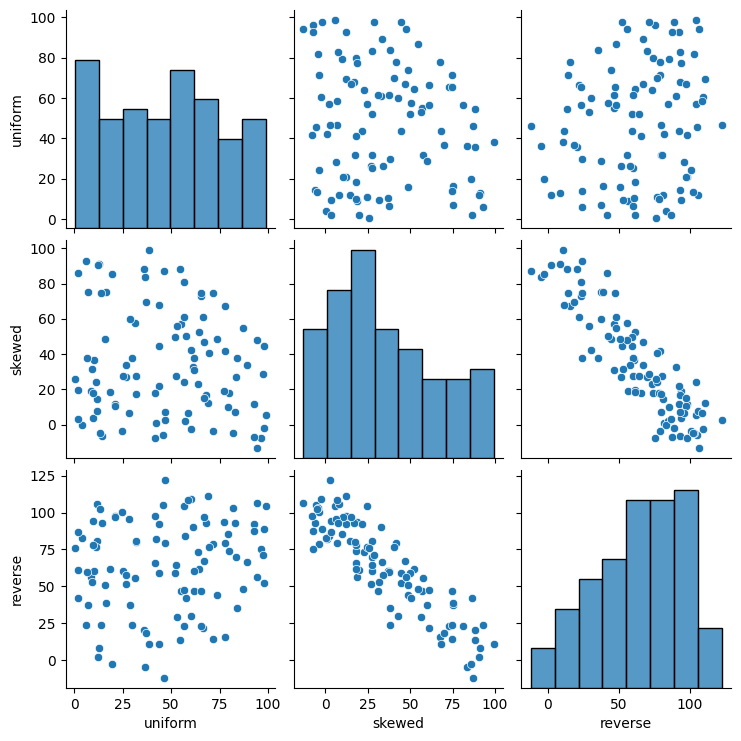

In [7]:
## initialize df from series
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])
## pairplot
sns.pairplot(df)

###### df.corr()

In [8]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


##### Week 6

###### Line Plots

/tmp/ipykernel_3289/821426618.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

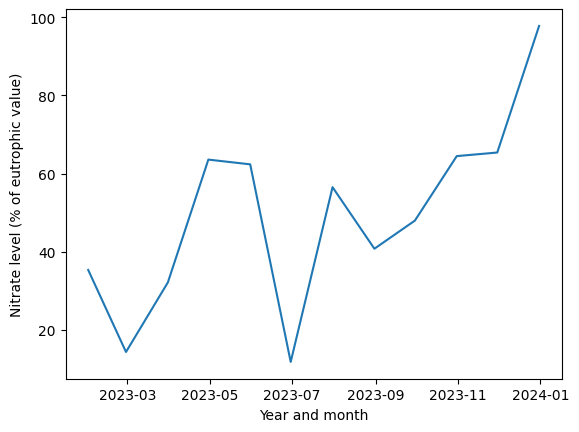

In [13]:
# Week 6
## generate first series
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
## first line plot
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_3289/911992633.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

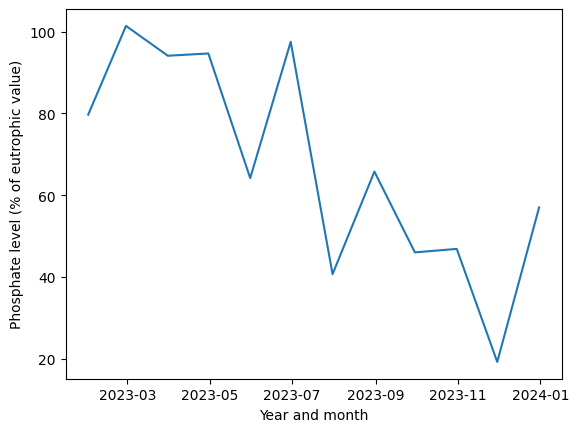

In [14]:
## generate second series
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
## second line plot
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

###### Area Plot

<Axes: >

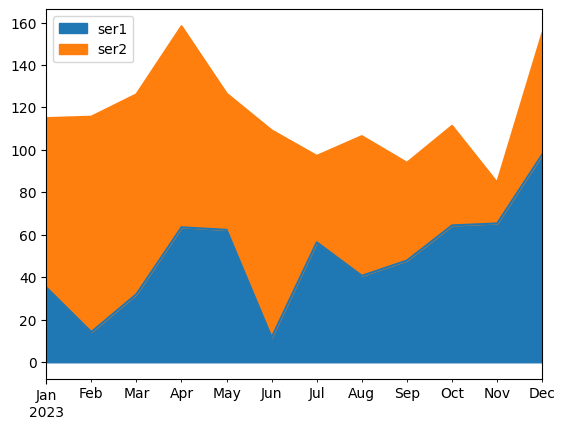

In [15]:
## intialize dataframe from both series
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
## area plot
df.plot.area()

***
### **Week 8-12**

#### 🔢 Multivariate Functions

##### Week 8

###### Heatmap

In [ ]:
# Week 8
## intialize series
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples)
## build df
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")
## first heatmap
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

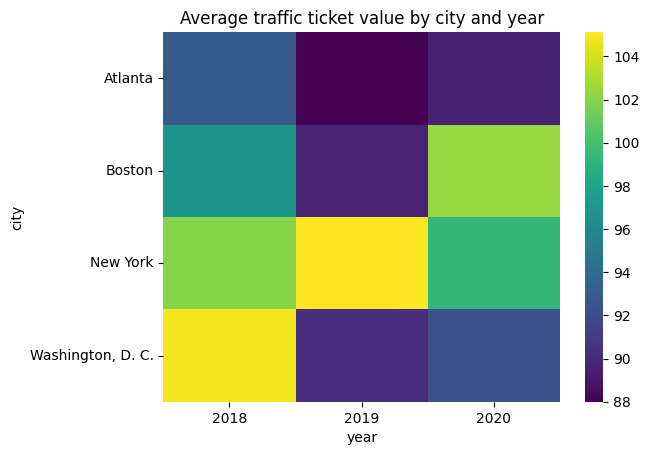

In [18]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean")
## second heatmap
ax2 = sns.heatmap(pivot2, cmap = "viridis")
ax2.set_title("Average traffic ticket value by city and year")

###### Bubblemap

Text(0, 0.5, 'width of branches')

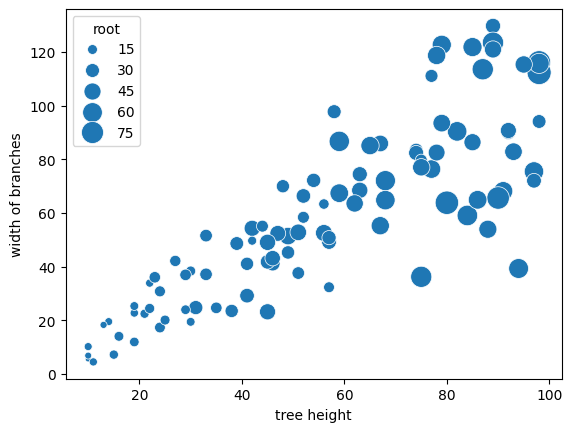

In [19]:
## generate series
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
## make dataframe
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
## scatterplot
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

###### PCA

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [26]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)

print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")

mu_h, mu_w, mu_r = df2.mean().values

print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")

df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r

print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944689 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [27]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)

print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [28]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

-1.6653345369377348e-16


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

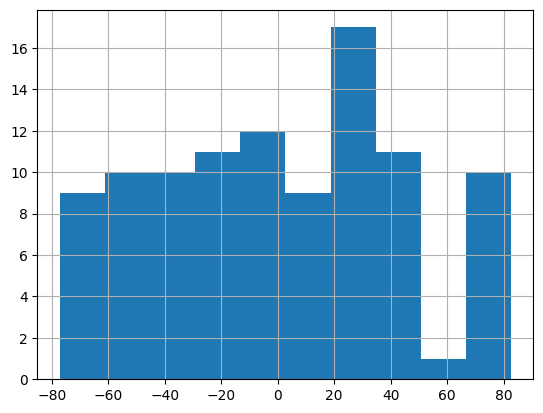

In [29]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [30]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

np.float64(0.0)

###### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

In [31]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [32]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

Predicting the third principal component from the first and second

In [33]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [34]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273173

In [35]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.55375616e-14],
       [1.55375616e-14, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

##### Week 9

###### PCA ... again

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

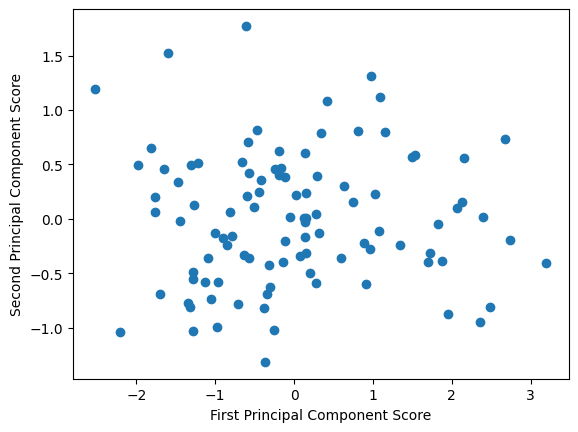

In [36]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)

print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])

plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

##### Week 10

###### Random Forest

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [38]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [39]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))

test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.40446903790544014
RMSE when predicting testing data:
1.0666204347667474
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

###### Cross Validation

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [40]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [41]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851425903159186


In [42]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12289873, -1.09373829, -1.08514259])

Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [43]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

##### Week 11

###### Random Forest ... again

In [44]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

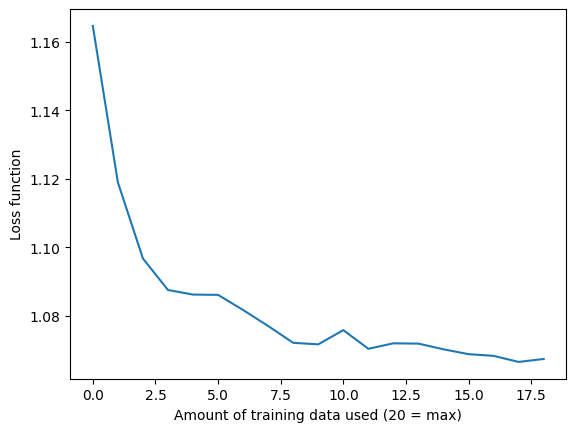

In [46]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [47]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

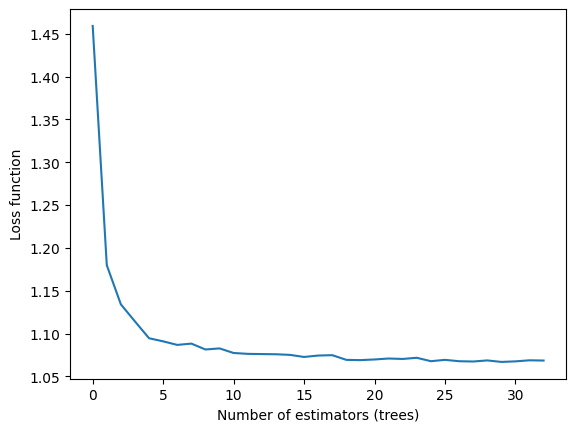

In [48]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

##### Week 12

Text(0, 0.5, 'Number of visitors')

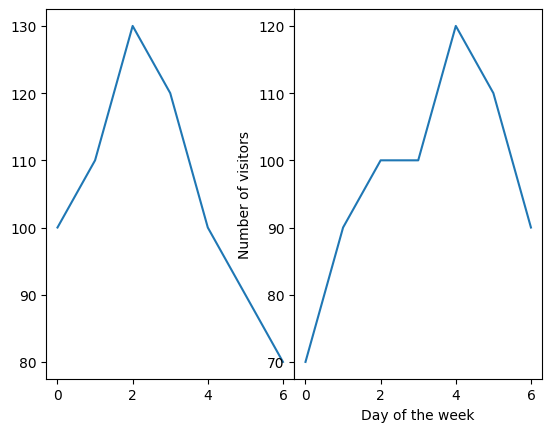

In [49]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

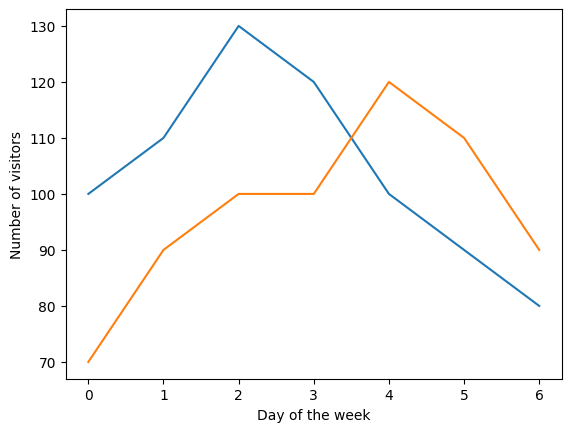

In [50]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

### 2026-02 FRED-MD (transformations)

###### Stationary transformations

In [624]:
"""
FRED-MD Stationarity Transformations
Based on McCracken & Ng (2016) tcode specification.

Transformation codes (tcode):
    1 - Level (no transformation)
    2 - First difference: Δx_t = x_t - x_{t-1}
    3 - Second difference: Δ²x_t = Δx_t - Δx_{t-1}
    4 - Log: log(x_t)
    5 - First difference of log (growth rate): Δlog(x_t) = log(x_t) - log(x_{t-1})
    6 - Second difference of log: Δ²log(x_t)
    7 - First difference of percent change: Δ(x_t/x_{t-1} - 1)

Usage:
    import pandas as pd
    df = pd.read_csv("FRED_MD.csv")
    df_transformed = transform_fredmd(df)
"""

import numpy as np
import pandas as pd


# -------------------------------------------------------------------
# tcode assignments for each FRED-MD variable (McCracken & Ng 2016)
# -------------------------------------------------------------------
TCODES = {
    "RPI": 5, "W875RX1": 5, "DPCERA3M086SBEA": 5, "CMRMTSPLx": 5,
    "RETAILx": 5, "INDPRO": 5, "IPFPNSS": 5, "IPFINAL": 5,
    "IPCONGD": 5, "IPDCONGD": 5, "IPNCONGD": 5, "IPBUSEQ": 5,
    "IPMAT": 5, "IPDMAT": 5, "IPNMAT": 5, "IPMANSICS": 5,
    "IPB51222S": 5, "IPFUELS": 5, "CUMFNS": 2,
    "HWI": 2, "HWIURATIO": 2, "CLF16OV": 5, "CE16OV": 5,
    "UNRATE": 2, "UEMPMEAN": 2, "UEMPLT5": 5, "UEMP5TO14": 5,
    "UEMP15OV": 5, "UEMP15T26": 5, "UEMP27OV": 5, "CLAIMSx": 5,
    "PAYEMS": 5, "USGOOD": 5, "CES1021000001": 5, "USCONS": 5,
    "MANEMP": 5, "DMANEMP": 5, "NDMANEMP": 5, "SRVPRD": 5,
    "USTPU": 5, "USWTRADE": 5, "USTRADE": 5, "USFIRE": 5,
    "USGOVT": 5, "CES0600000007": 1, "AWOTMAN": 2, "AWHMAN": 1,
    "HOUST": 4, "HOUSTNE": 4, "HOUSTMW": 4, "HOUSTS": 4, "HOUSTW": 4,
    "PERMIT": 4, "PERMITNE": 4, "PERMITMW": 4, "PERMITS": 4, "PERMITW": 4,
    "ACOGNO": 5, "AMDMNOx": 5, "ANDENOx": 5, "AMDMUOx": 5,
    "BUSINVx": 5, "ISRATIOx": 2,
    "M1SL": 6, "M2SL": 6, "M2REAL": 5, "BOGMBASE": 6,
    "TOTRESNS": 6, "NONBORRES": 7, "BUSLOANS": 6, "REALLN": 6,
    "NONREVSL": 6, "CONSPI": 2,
    "S&P 500": 5, "S&P div yield": 2, "S&P PE ratio": 5,
    "FEDFUNDS": 2, "CP3Mx": 2, "TB3MS": 2, "TB6MS": 2,
    "GS1": 2, "GS5": 2, "GS10": 2, "AAA": 2, "BAA": 2,
    "COMPAPFFx": 1, "TB3SMFFM": 1, "TB6SMFFM": 1,
    "T1YFFM": 1, "T5YFFM": 1, "T10YFFM": 1, "AAAFFM": 1, "BAAFFM": 1,
    "TWEXAFEGSMTHx": 5, "EXSZUSx": 5, "EXJPUSx": 5,
    "EXUSUKx": 5, "EXCAUSx": 5,
    "WPSFD49207": 6, "WPSFD49502": 6, "WPSID61": 6, "WPSID62": 6,
    "OILPRICEx": 6, "PPICMM": 6, "CPIAUCSL": 6, "CPIAPPSL": 6,
    "CPITRNSL": 6, "CPIMEDSL": 6, "CUSR0000SAC": 6, "CUSR0000SAD": 6,
    "CUSR0000SAS": 6, "CPIULFSL": 6, "CUSR0000SA0L2": 6,
    "CUSR0000SA0L5": 6, "PCEPI": 6, "DDURRG3M086SBEA": 6,
    "DNDGRG3M086SBEA": 6, "DSERRG3M086SBEA": 6,
    "CES0600000008": 6, "CES2000000008": 6, "CES3000000008": 6,
    "UMCSENTx": 2, "DTCOLNVHFNM": 6, "DTCTHFNM": 6,
    "INVEST": 6, "VIXCLSx": 1,
}

TCODE_LABELS = {
    1: "Level (no transformation)",
    2: "First difference",
    3: "Second difference",
    4: "Log",
    5: "First difference of log (growth rate)",
    6: "Second difference of log",
    7: "First difference of percent change",
}


# -------------------------------------------------------------------
# Single-series transformation
# -------------------------------------------------------------------
def _apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    """
    Apply a single tcode transformation to a pandas Series.

    Parameters
    ----------
    series : pd.Series
        Raw data series (numeric).
    tcode : int
        Transformation code 1-7.

    Returns
    -------
    pd.Series
        Transformed series (same index, NaNs introduced where needed).
    """
    x = series.astype(float)

    if tcode == 1:
        # Level — no change
        return x

    elif tcode == 2:
        # First difference
        return x.diff()

    elif tcode == 3:
        # Second difference
        return x.diff().diff()

    elif tcode == 4:
        # Natural log
        return np.log(x)

    elif tcode == 5:
        # First difference of log (approximate % growth rate)
        return np.log(x).diff()

    elif tcode == 6:
        # Second difference of log
        return np.log(x).diff().diff()

    elif tcode == 7:
        # First difference of percent change
        pct = x.pct_change()
        return pct.diff()

    else:
        raise ValueError(f"Unknown tcode: {tcode}. Must be 1-7.")


# -------------------------------------------------------------------
# Full dataset transformation
# -------------------------------------------------------------------
def transform_fredmd(
    df: pd.DataFrame,
    date_col: str = "sasdate",
    tcodes: dict = None,
    drop_first_rows: int = 2,
) -> pd.DataFrame:
    """
    Transform a raw FRED-MD DataFrame to stationarity using official tcodes.

    Parameters
    ----------
    df : pd.DataFrame
        Raw FRED-MD data. Expects a date column (sasdate) and one column
        per variable. The first row of the actual CSV is the tcode row —
        drop it before passing if you loaded the CSV directly with pandas.
    date_col : str
        Name of the date column. Default: "sasdate".
    tcodes : dict, optional
        Custom {variable: tcode} mapping. Defaults to the official TCODES
        from McCracken & Ng (2016). Useful for overriding individual series.
    drop_first_rows : int
        Number of leading rows to drop after transformation (they will be
        NaN due to differencing). Default: 2 (safe for tcode 6 & 7).

    Returns
    -------
    pd.DataFrame
        Transformed DataFrame with sasdate preserved as-is and all other
        columns transformed. Leading NaN rows are dropped.

    Example
    -------
        import pandas as pd
        raw = pd.read_csv("current.csv")

        # The first data row in FRED-MD CSVs is the tcode row — remove it
        raw = raw[raw[\"sasdate\"] != \"transform\"].copy()
        raw = raw.reset_index(drop=True)

        transformed = transform_fredmd(raw)
        print(transformed.head())
    """
    if tcodes is None:
        tcodes = TCODES

    result = pd.DataFrame()

    if date_col in df.columns:
        result[date_col] = df[date_col].values

    skipped = []
    for col in df.columns:
        if col == date_col:
            continue

        if col not in tcodes:
            skipped.append(col)
            result[col] = df[col]
            continue

        tcode = tcodes[col]
        result[col] = _apply_tcode(df[col], tcode).values

    if skipped:
        print(f"[Warning] No tcode found for {len(skipped)} column(s), left as-is: {skipped}")

    if drop_first_rows > 0:
        result = result.iloc[drop_first_rows:].reset_index(drop=True)

    return result


# -------------------------------------------------------------------
# Convenience helper — transform a single named variable
# -------------------------------------------------------------------
def transform_variable(series: pd.Series, variable_name: str, tcodes: dict = None) -> pd.Series:
    """
    Transform a single FRED-MD variable by name.

    Parameters
    ----------
    series : pd.Series
        Raw data for the variable.
    variable_name : str
        FRED-MD variable name (used to look up its tcode).
    tcodes : dict, optional
        Custom tcode mapping. Defaults to official TCODES.

    Returns
    -------
    pd.Series
        Transformed series.

    Example
    -------
        transformed_cpi = transform_variable(df["CPIAUCSL"], "CPIAUCSL")
    """
    if tcodes is None:
        tcodes = TCODES

    if variable_name not in tcodes:
        raise KeyError(
            f"'{variable_name}' not found in tcode map. "
            f"Pass a custom tcodes dict or check the variable name."
        )

    tcode = tcodes[variable_name]
    print(f"{variable_name}: applying tcode {tcode} — {TCODE_LABELS[tcode]}")
    return _apply_tcode(series, tcode)


# -------------------------------------------------------------------
# Quick demo when run as a script
# -------------------------------------------------------------------
if __name__ == "__main__":
    # Synthetic demo — replace with your actual FRED-MD CSV path
    np.random.seed(42)
    n = 60
    dates = pd.date_range("1990-01", periods=n, freq="MS").strftime("%m/%d/%Y")

    demo_df = pd.DataFrame({
        "sasdate": dates,
        "CPIAUCSL": 130 + np.cumsum(np.random.normal(0.3, 0.1, n)),
        "UNRATE":    5  + np.cumsum(np.random.normal(0,   0.1, n)),
        "FEDFUNDS":  4  + np.cumsum(np.random.normal(0,   0.05, n)),
        "INDPRO":    90 + np.cumsum(np.random.normal(0.2, 0.3, n)),
        "S&P 500":  400 + np.cumsum(np.random.normal(1,   5,   n)),
    })

    print("=== Raw data (first 5 rows) ===")
    print(demo_df.head(), "\n")

    transformed = transform_fredmd(demo_df)

    print("=== Transformed data (first 5 rows) ===")
    print(transformed.head(), "\n")

    print("=== Single variable example: CPIAUCSL ===")
    cpi_t = transform_variable(demo_df["CPIAUCSL"], "CPIAUCSL")
    print(cpi_t.head(10))

=== Raw data (first 5 rows) ===
      sasdate  CPIAUCSL  UNRATE  FEDFUNDS  INDPRO  S&P 500
0  01/01/1990  130.3497  4.9521    4.0396 90.3877 397.0374
1  02/01/1990  130.6358  4.9335    3.9941 90.3306 397.4637
2  03/01/1990  131.0006  4.8229    4.0642 90.2093 400.9887
3  04/01/1990  131.4529  4.7033    3.9941 90.5540 406.3174
4  05/01/1990  131.7295  4.7845    4.0235 90.6870 401.3159 

=== Transformed data (first 5 rows) ===
      sasdate  CPIAUCSL  UNRATE  FEDFUNDS  INDPRO  S&P 500
0  03/01/1990    0.0006 -0.1106    0.0701 -0.0013   0.0088
1  04/01/1990    0.0007 -0.1196   -0.0701  0.0038   0.0132
2  05/01/1990   -0.0013  0.0813    0.0293  0.0015  -0.0124
3  06/01/1990   -0.0000  0.1356    0.1095  0.0046  -0.0017
4  07/01/1990    0.0014 -0.0072   -0.0495  0.0037  -0.0034 

=== Single variable example: CPIAUCSL ===
CPIAUCSL: applying tcode 6 — Second difference of log
0       NaN
1       NaN
2    0.0006
3    0.0007
4   -0.0013
5   -0.0000
6    0.0014
7   -0.0006
8   -0.0009
9    0.0008


In [625]:
macro_fred_df = transform_fredmd(macro_fred_df)

/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:39

In [626]:
def adf_score(series: pd.Series) -> float:
    """
    Run ADF test on a series and return the p-value.
    Returns NaN if the test cannot be run (e.g. too many NaNs).
    """
    clean = series.dropna()
    if len(clean) < 20:
        return np.nan
    try:
        result = adfuller(clean, autolag="AIC")
        return round(result[1], 4)  # p-value
    except Exception:
        return np.nan


def stationarity_report(
    df_raw: pd.DataFrame,
    date_col: str = "sasdate",
    save_path: str = "stationarity_report.xlsx",
) -> pd.DataFrame:
    """
    Compare ADF test p-values before and after FRED-MD transformations.

    Parameters
    ----------
    df_raw    : Raw FRED-MD DataFrame (before transformation)
    date_col  : Name of the date column. Default: 'sasdate'
    save_path : Output Excel file path

    Returns
    -------
    pd.DataFrame with columns:
        Variable      - series name
        ADF_Raw       - p-value on raw series
        ADF_Transformed - p-value on transformed series
        Stationary_Raw        - Yes/No at 5% significance
        Stationary_Transformed - Yes/No at 5% significance

    Interpretation
    --------------
    ADF p-value < 0.05  → reject unit root → series is stationary
    ADF p-value >= 0.05 → fail to reject  → series is non-stationary
    """
    df_transformed = transform_fredmd(df_raw, date_col=date_col)

    records = []
    for col in df_raw.columns:
        if col == date_col:
            continue

        p_raw   = adf_score(df_raw[col])
        p_trans = adf_score(df_transformed[col]) if col in df_transformed.columns else np.nan

        records.append({
            "Variable":               col,
            "ADF p-value (Raw)":      p_raw,
            "ADF p-value (Transformed)": p_trans,
            "Stationary (Raw)":       "Yes" if (p_raw   is not np.nan and p_raw   < 0.05) else "No",
            "Stationary (Transformed)": "Yes" if (p_trans is not np.nan and p_trans < 0.05) else "No",
        })

    report = pd.DataFrame(records)
    _save_report_excel(report, save_path)
    print(f"Stationarity report saved to: {save_path}")
    return report


def _save_report_excel(report: pd.DataFrame, path: str):
    """Style and save the stationarity report as an Excel file."""
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Stationarity Report"

    # --- Styles ---
    thin        = Side(style="thin", color="CCCCCC")
    border      = Border(left=thin, right=thin, top=thin, bottom=thin)
    header_font = Font(name="Arial", bold=True, color="FFFFFF", size=11)
    header_fill = PatternFill("solid", start_color="1F4E79")
    center      = Alignment(horizontal="center", vertical="center")
    alt_fill    = PatternFill("solid", start_color="EBF3FB")
    white_fill  = PatternFill("solid", start_color="FFFFFF")
    green_fill  = PatternFill("solid", start_color="E2EFDA")
    red_fill    = PatternFill("solid", start_color="FCE4D6")

    col_widths  = [22, 22, 26, 20, 24]
    for i, w in enumerate(col_widths, start=1):
        ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = w

    # --- Header row ---
    for col_idx, col_name in enumerate(report.columns, start=1):
        cell = ws.cell(row=1, column=col_idx, value=col_name)
        cell.font      = header_font
        cell.fill      = header_fill
        cell.alignment = center
        cell.border    = border
    ws.row_dimensions[1].height = 20
    ws.freeze_panes = "A2"

    # --- Data rows ---
    for row_idx, row in enumerate(report.itertuples(index=False), start=2):
        fill = alt_fill if row_idx % 2 == 0 else white_fill
        values = list(row)

        for col_idx, val in enumerate(values, start=1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.font      = Font(name="Arial", size=10)
            cell.alignment = center if col_idx > 1 else Alignment(vertical="center")
            cell.border    = border

            # Color-code the Stationary Yes/No columns
            if col_idx in (4, 5):
                if val == "Yes":
                    cell.fill = green_fill
                    cell.font = Font(name="Arial", size=10, color="375623", bold=True)
                elif val == "No":
                    cell.fill = red_fill
                    cell.font = Font(name="Arial", size=10, color="843C0C", bold=True)
                else:
                    cell.fill = fill
            else:
                cell.fill = fill

    wb.save(path)


# --- Example usage ---
if __name__ == "__main__":
    raw = pd.read_csv("../2026-02-MD_edited.csv")
    raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

    report = stationarity_report(raw, save_path="stationarity_report.xlsx")
    print(report.head(10))

/tmp/ipykernel_1064/249560177.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[col] = _apply_tcode(df[col], tcode).values
/tmp/ipykernel_1064/249560177.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[col] = _apply_tcode(df[col], tcode).values
/tmp/ipykernel_1064/249560177.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de

Stationarity report saved to: stationarity_report.xlsx
          Variable  ADF p-value (Raw)  ...  Stationary (Raw) Stationary (Transformed)
0              RPI             1.0000  ...                No                      Yes
1          W875RX1             0.9990  ...                No                      Yes
2  DPCERA3M086SBEA             1.0000  ...                No                      Yes
3        CMRMTSPLx             0.9840  ...                No                      Yes
4          RETAILx             1.0000  ...                No                      Yes
5           INDPRO             0.7054  ...                No                      Yes
6          IPFPNSS             0.4578  ...                No                      Yes
7          IPFINAL             0.4559  ...                No                      Yes
8          IPCONGD             0.1342  ...                No                      Yes
9         IPDCONGD             0.5790  ...                No                      Yes

#### Treat outliers

In [627]:
def treat_outliers(
    df: pd.DataFrame,
    date_col: str = "sasdate",
    method: str = "winsorize",
    winsor_limits: tuple = (0.01, 0.01),
    iqr_multiplier: float = 3.0,
) -> pd.DataFrame:
    """
    Apply outlier treatment to a transformed FRED-MD DataFrame.
    Designed to run AFTER transform_fredmd() as a standalone cell.

    Parameters
    ----------
    df              : Transformed FRED-MD DataFrame (output of transform_fredmd())
    date_col        : Name of the date column. Default: 'sasdate'
    method          : Outlier treatment method:
                        'winsorize' - clips extreme values to percentile bounds (recommended)
                        'iqr'       - clips values beyond N * IQR from Q1/Q3
    winsor_limits   : (lower, upper) percentile limits for winsorization.
                      Default (0.01, 0.01) clips bottom and top 1%
    iqr_multiplier  : Multiplier for IQR method. Default 3.0 (more conservative than 1.5)
                      Use 1.5 for aggressive clipping, 3.0 for extreme outliers only

    Returns
    -------
    pd.DataFrame    : Outlier-treated DataFrame, same shape as input

    Notes
    -----
    - date_col is never touched
    - Treatment is applied column by column so each series
      uses its own distribution bounds — not a global threshold
    - IQR multiplier of 3.0 is recommended for macro time series
      since large moves during recessions are real signals not errors
    - Winsorize at 1% is the standard in macro forecasting literature

    Example
    -------
        transformed    = transform_fredmd(raw)
        df_clean       = treat_outliers(transformed, method="winsorize")
    """
    df_treated = df.copy()
    numeric_cols = [c for c in df.columns if c != date_col]

    outlier_log = {}

    for col in numeric_cols:
        series = df_treated[col].copy()
        n_null = series.isna().sum()
        clean  = series.dropna()

        if len(clean) < 20:
            continue

        original_min = clean.min()
        original_max = clean.max()

        if method == "winsorize":
            treated = pd.Series(
                mstats.winsorize(clean, limits=winsor_limits),
                index=clean.index
            )

        elif method == "iqr":
            Q1  = clean.quantile(0.25)
            Q3  = clean.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - iqr_multiplier * IQR
            upper = Q3 + iqr_multiplier * IQR
            treated = clean.clip(lower=lower, upper=upper)

        else:
            raise ValueError(f"method must be 'winsorize' or 'iqr'. Got: {method}")

        # Count how many values were clipped
        n_clipped = (treated != clean).sum()

        if n_clipped > 0:
            outlier_log[col] = {
                "n_clipped":    n_clipped,
                "original_min": round(original_min, 6),
                "original_max": round(original_max, 6),
                "treated_min":  round(treated.min(), 6),
                "treated_max":  round(treated.max(), 6),
            }

        # Write treated values back, preserving NaN positions
        df_treated.loc[treated.index, col] = treated

    # --- Summary report ---
    print(f"=== Outlier Treatment Summary ===")
    print(f"Method          : {method}")
    if method == "winsorize":
        print(f"Limits          : bottom {winsor_limits[0]*100:.1f}% / top {winsor_limits[1]*100:.1f}%")
    else:
        print(f"IQR Multiplier  : {iqr_multiplier}")
    print(f"Columns treated : {len(numeric_cols)}")
    print(f"Columns clipped : {len(outlier_log)}\n")

    if outlier_log:
        log_df = pd.DataFrame(outlier_log).T
        log_df["n_clipped"] = log_df["n_clipped"].astype(int)
        print(log_df.sort_values("n_clipped", ascending=False).to_string())

    return df_treated


# --- Apply after transform_fredmd() ---

# Option 1: Winsorize at 1% (recommended for macro time series)
macro_fred_df = treat_outliers(
    df            = macro_fred_df,
    date_col      = "sasdate",
    method        = "winsorize",
    winsor_limits = (0.01, 0.01)
)

# Option 2: IQR method — more conservative, only clips extreme outliers
# macro_fred_df = treat_outliers(
#     df             = macro_fred_df,
#     date_col       = "sasdate",
#     method         = "iqr",
#     iqr_multiplier = 3.0
# )

# --- Verify shape unchanged ---
print(f"\nShape after treatment: {macro_fred_df.shape}")
print(f"NaNs after treatment:  {macro_fred_df.isna().sum().sum()}")

=== Outlier Treatment Summary ===
Method          : winsorize
Limits          : bottom 1.0% / top 1.0%
Columns treated : 126
Columns clipped : 81

                 n_clipped  original_min  original_max  treated_min  treated_max
CUMFNS                  16       -7.6896       13.9232      -2.1907       2.5492
BAAFFM                  16       -4.0500        8.8200      -2.5700       7.2900
NONBORRES               16          -inf           inf    -222.2901     222.8790
GS5                     16       -2.5000        2.2500      -0.9200       0.9900
GS1                     16       -4.4200        3.4100      -1.3000       1.3700
TB3MS                   16       -4.3400        3.1100      -1.5000       1.6800
TB6MS                   16       -4.3200        2.8800      -1.3600       1.3500
FEDFUNDS                16       -7.0500        5.1200      -1.6600       1.6200
S&P div yield           16       -0.7280        0.7054      -0.4571       0.3563
T10YFFM                 16       -6.5100   

###### Macro Plots

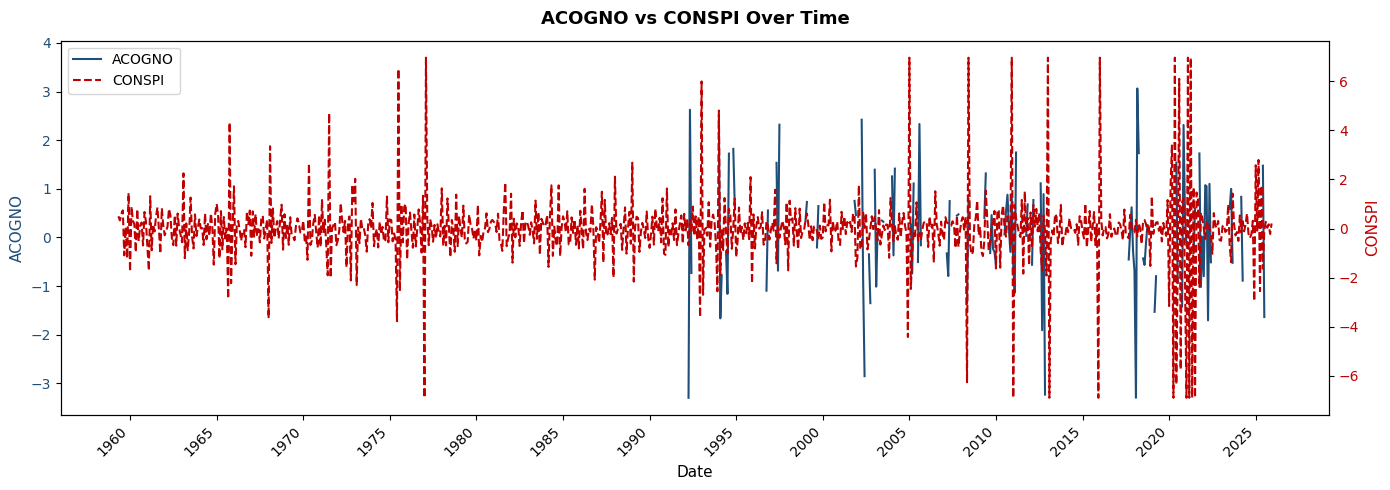

In [628]:
def plot_fredmd_dual(df, var1, var2, date_col="sasdate", figsize=(14, 5)):
    """
    Plot two FRED-MD variables over time on dual y-axes.

    Parameters
    ----------
    df       : transformed FRED-MD DataFrame
    var1     : primary variable (left y-axis)
    var2     : secondary variable (right y-axis)
    date_col : name of the date column (default: 'sasdate')
    figsize  : figure size tuple
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    fig, ax1 = plt.subplots(figsize=figsize)

    # --- Left axis: var1 ---
    color1 = "#1F4E79"
    ax1.plot(df[date_col], df[var1], color=color1, linewidth=1.5, label=var1)
    ax1.set_ylabel(var1, color=color1, fontsize=11)
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.set_xlabel("Date", fontsize=11)

    # --- Right axis: var2 ---
    ax2 = ax1.twinx()
    color2 = "#C00000"
    ax2.plot(df[date_col], df[var2], color=color2, linewidth=1.5, linestyle="--", label=var2)
    ax2.set_ylabel(var2, color=color2, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=color2)

    # --- Formatting ---
    ax1.xaxis.set_major_locator(mdates.YearLocator(5))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

    plt.title(f"{var1} vs {var2} Over Time", fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("fredmd_dual_plot.png", dpi=150, bbox_inches="tight")
    plt.show()


# --- Example usage ---
plot_fredmd_dual(macro_fred_df, var1="ACOGNO", var2="CONSPI")

## Analysis Section

In [45]:
macro_fred_df = pd.read_csv("../2026-02-MD_edited.csv")
cc_risk_df = pd.read_csv("../credit_risk_dataset.csv")

In [46]:
pd.options.display.float_format = '{:,.4f}'.format

### Consumer Credit Risk Dataset

#### EDA pre-processing prep

##### Convert categories into numberic and label ordinal, nominal, and binary

In [47]:
# create ordinal number column for loan_grade
mapping = {'A': 1, 'B': 2, 'C': 3,'D': 4, 'E': 5, 'F': 6, 'G': 7}
cc_risk_df['CAT_loan_grade_ordinal'] = cc_risk_df['loan_grade'].map(mapping)

# create binary column flag for cb_person_default_on_file
mapping = {'Y': 1, 'N': 0}
cc_risk_df['CAT_cb_person_default_on_file_binary'] = cc_risk_df['cb_person_default_on_file'].map(mapping)

# create nominal column flag for person_home_ownership
mapping = {'OWN': 1, 'MORTGAGE': 2,'RENT': 3, 'OTHER': 4}
cc_risk_df['CAT_person_home_ownership_nominal'] = cc_risk_df['person_home_ownership'].map(mapping)

# create nominal column flag for loan_intent
mapping = {'DEBTCONSOLIDATION': 1, 'EDUCATION': 2, 'HOMEIMPROVEMENT': 3,'MEDICAL': 4, 'PERSONAL': 5, 'VENTURE': 6}
cc_risk_df['CAT_loan_intent_nominal'] = cc_risk_df['loan_intent'].map(mapping)

##### Drop null: loan_int_rate and person_emp_length (-3,943)

In [19]:
cc_risk_df = cc_risk_df.dropna(subset=['loan_int_rate','person_emp_length'])

##### New integer column for loan_int_rate

In [20]:

cc_risk_df["loan_int_rate_integer"] = np.floor(cc_risk_df['loan_int_rate']).astype(int)
#cc_risk_df["loan_int_rate_rounded"] = np.round(cc_risk_df['loan_int_rate']).astype(int)

/tmp/ipykernel_2676/1014600252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cc_risk_df["loan_int_rate_integer"] = np.floor(cc_risk_df['loan_int_rate']).astype(int)


#### EDA

##### Null count

In [21]:
cc_risk_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   person_age                            28638 non-null  int64  
 1   person_income                         28638 non-null  int64  
 2   person_home_ownership                 28638 non-null  object 
 3   person_emp_length                     28638 non-null  float64
 4   loan_intent                           28638 non-null  object 
 5   loan_grade                            28638 non-null  object 
 6   loan_amnt                             28638 non-null  int64  
 7   loan_int_rate                         28638 non-null  float64
 8   loan_status                           28638 non-null  int64  
 9   loan_percent_income                   28638 non-null  float64
 10  cb_person_default_on_file             28638 non-null  object 
 11  cb_person_cred_hist_

##### Basic stats

In [22]:
cc_risk_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,CAT_loan_grade_ordinal,CAT_cb_person_default_on_file_binary,CAT_person_home_ownership_nominal,CAT_loan_intent_nominal,loan_int_rate_integer
count,28638.000000,2.863800e+04,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000
mean,27.727216,6.664937e+04,4.788672,9656.493121,11.039867,0.216600,0.169488,5.793736,2.228158,0.178190,2.438124,3.531322,10.461974
std,6.310441,6.235645e+04,4.154627,6329.683361,3.229372,0.411935,0.106393,4.038483,1.170746,0.382679,0.637051,1.729816,3.261368
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,1.000000,0.000000,1.000000,1.000000,5.000000
25%,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,1.000000,0.000000,2.000000,2.000000,7.000000
50%,26.000000,5.595600e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,2.000000,0.000000,3.000000,4.000000,10.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000,3.000000,0.000000,3.000000,5.000000,13.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,7.000000,1.000000,4.000000,6.000000,23.000000


##### loan_grade hist

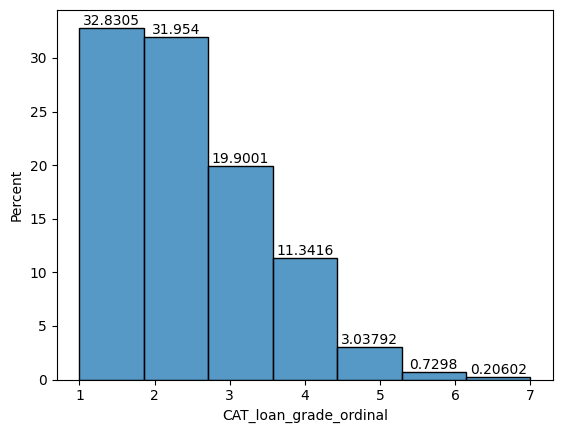

In [ ]:
ax = sns.histplot(cc_risk_df['CAT_loan_grade_ordinal'], stat='percent', bins=7)
for container in ax.containers:
    ax.bar_label(container)

##### Default hist

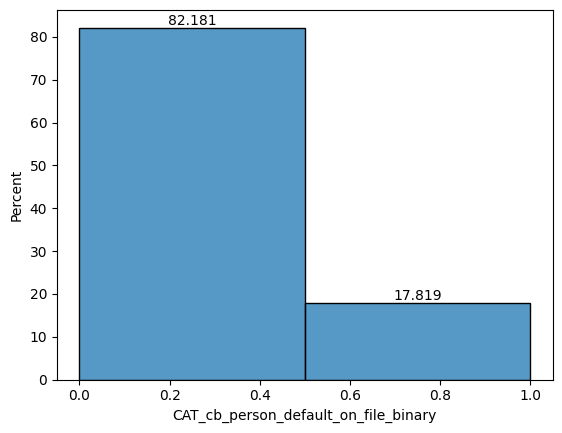

In [ ]:
# CAT_cb_person_default_on_file_binary

ax = sns.histplot(cc_risk_df['CAT_cb_person_default_on_file_binary'], stat='percent', bins=2)
for container in ax.containers:
    ax.bar_label(container)

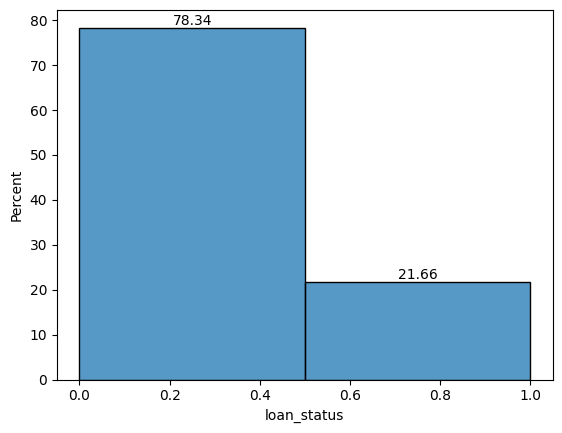

In [ ]:
# loan_status

ax = sns.histplot(cc_risk_df['loan_status'], stat='percent', bins=2)
for container in ax.containers:
    ax.bar_label(container)

##### Heatmap (Multi)

Text(0.5, 1.0, 'Avg. Interest Rate By Grade and Home Ownership')

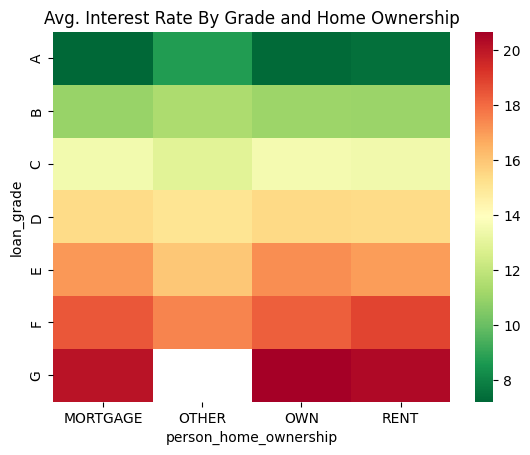

In [12]:
pivot = cc_risk_df.pivot_table(index = ["loan_grade"], columns = ["person_home_ownership"], values = "loan_int_rate", aggfunc = "mean")
ax = sns.heatmap(pivot, cmap = 'RdYlGn_r')
ax.set_title("Avg. Interest Rate By Grade and Home Ownership")

##### Double Line Plot (Multi)*

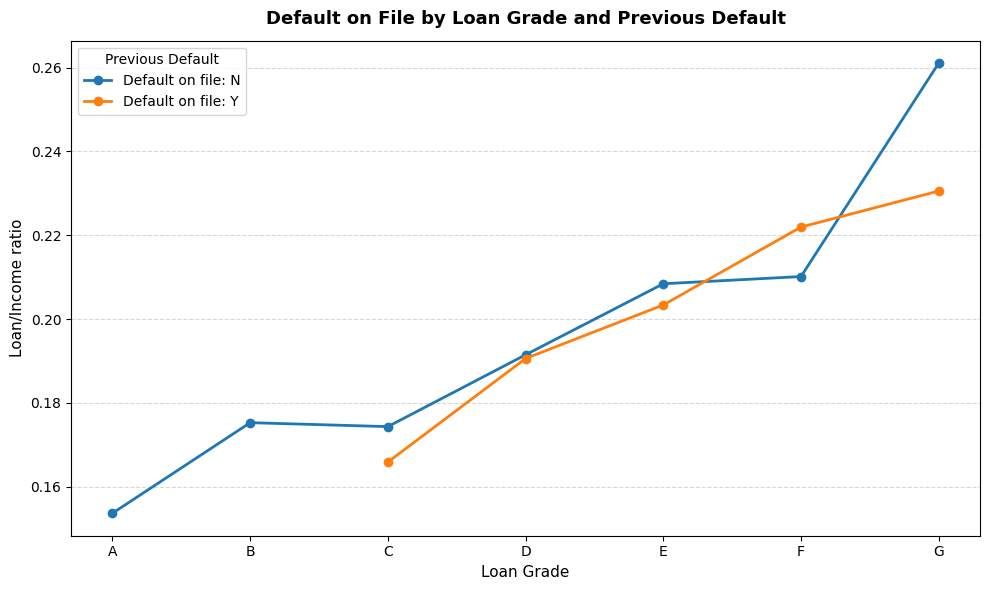

In [16]:
pivot = cc_risk_df.pivot_table(
    index="loan_grade",
    columns="cb_person_default_on_file",
    values="loan_percent_income",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 6))

for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", linewidth=2, label=f"Default on file: {col}")

ax.set_title("Default on File by Loan Grade and Previous Default",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Loan Grade", fontsize=11)
ax.set_ylabel("Loan/Income ratio", fontsize=11)
ax.legend(title="Previous Default", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##### Barplot (Multi)

loan_status       0       1
loan_grade                 
A           90.0400  9.9600
B           83.7200 16.2800
C           79.2700 20.7300
D           40.9500 59.0500
E           35.5800 64.4200
F           29.4600 70.5400
G            1.5600 98.4400


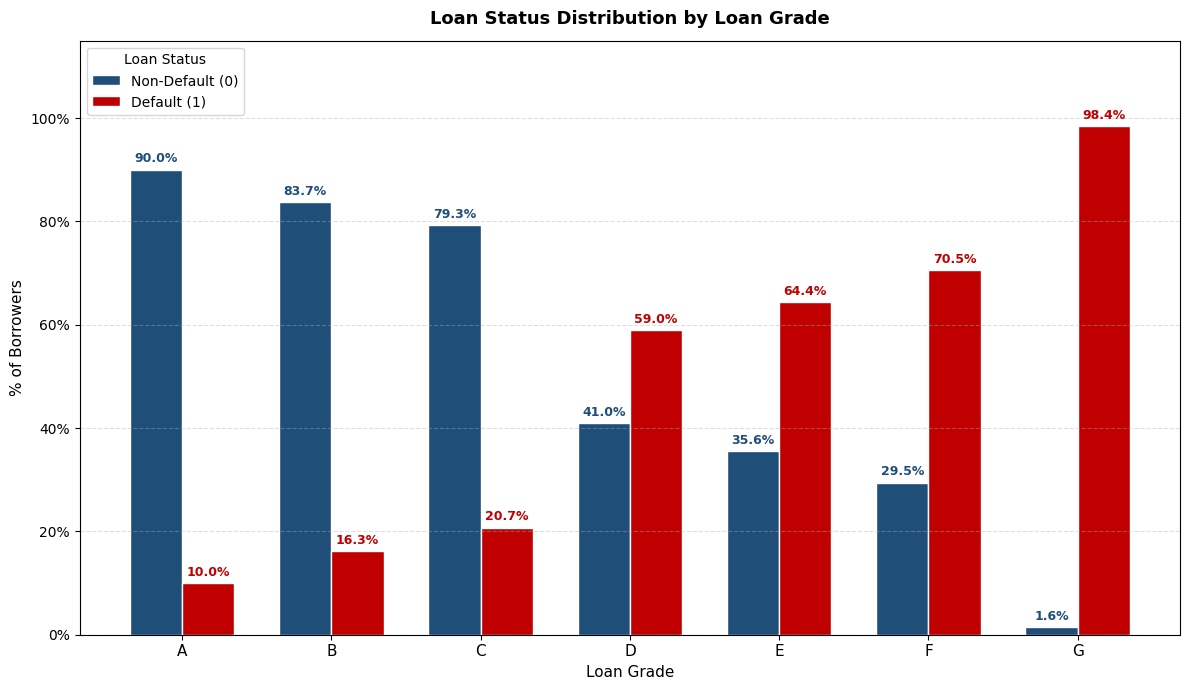

In [87]:
# --- Pivot: row % of loan_status by loan_grade ---
pivot = (cc_risk_df.groupby(["loan_grade", "loan_status"])
                   .size()
                   .unstack(fill_value=0))

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

print(pivot_pct.round(2))

# --- Plot ---
grades  = pivot_pct.index
x       = np.arange(len(grades))
width   = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars0 = ax.bar(x - width/2, pivot_pct[0], width,
               color="#1F4E79", edgecolor="white", label="Non-Default (0)")
bars1 = ax.bar(x + width/2, pivot_pct[1], width,
               color="#C00000", edgecolor="white", label="Default (1)")

# --- Labels on top of each bar ---
for bar in bars0:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#1F4E79")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#C00000")

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(grades, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title("Loan Status Distribution by Loan Grade",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Loan Grade", fontsize=11)
ax.set_ylabel("% of Borrowers", fontsize=11)
ax.legend(title="Loan Status", fontsize=10)
ax.set_ylim(0, 115)  # extra headroom for labels
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

##### Income boxplot

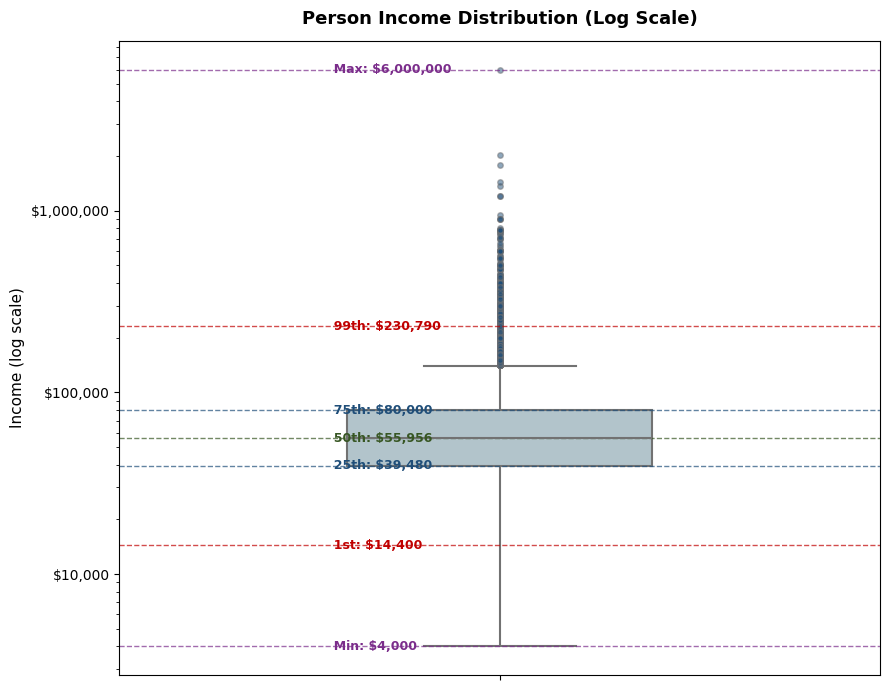

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=cc_risk_df, y="person_income", ax=ax,
            color="#AEC6CF", width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='#1F4E79', markersize=4, alpha=0.5))

ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Percentile + min/max labels ---
income = cc_risk_df["person_income"].dropna()

percentiles = {
    "Min":  income.min(),
    "1st":  np.percentile(income, 1),
    "25th": np.percentile(income, 25),
    "50th": np.percentile(income, 50),
    "75th": np.percentile(income, 75),
    "99th": np.percentile(income, 99),
    "Max":  income.max(),
}

colors = {
    "Min":  "#7B2D8B",
    "1st":  "#C00000",
    "25th": "#1F4E79",
    "50th": "#375623",
    "75th": "#1F4E79",
    "99th": "#C00000",
    "Max":  "#7B2D8B",
}

for label, val in percentiles.items():
    ax.axhline(y=val, linestyle="--", linewidth=1, color=colors[label], alpha=0.7)
    ax.text(
        x=0.27,
        y=val,
        s=f"  {label}: ${val:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color=colors[label],
        fontweight="bold",
        transform=ax.get_yaxis_transform()
    )

ax.set_title("Person Income Distribution (Log Scale)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Income (log scale)", fontsize=11)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

##### Loan amount boxplot

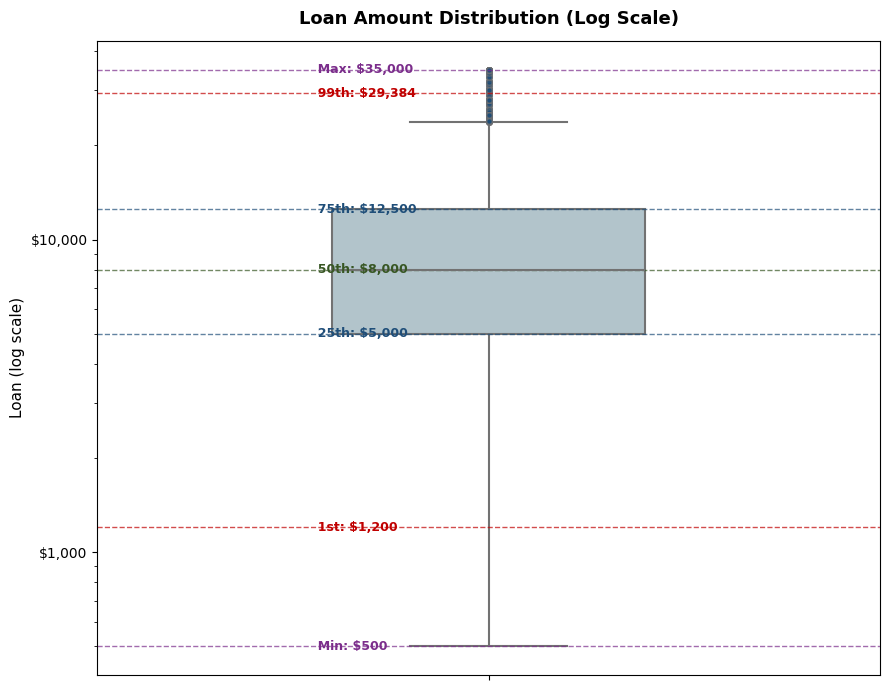

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=cc_risk_df, y="loan_amnt", ax=ax,
            color="#AEC6CF", width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='#1F4E79', markersize=4, alpha=0.5))

ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Percentile + min/max labels ---
tick = cc_risk_df["loan_amnt"].dropna()

percentiles = {
    "Min":  tick.min(),
    "1st":  np.percentile(tick, 1),
    "25th": np.percentile(tick, 25),
    "50th": np.percentile(tick, 50),
    "75th": np.percentile(tick, 75),
    "99th": np.percentile(tick, 99),
    "Max":  tick.max(),
}

colors = {
    "Min":  "#7B2D8B",
    "1st":  "#C00000",
    "25th": "#1F4E79",
    "50th": "#375623",
    "75th": "#1F4E79",
    "99th": "#C00000",
    "Max":  "#7B2D8B",
}

for label, val in percentiles.items():
    ax.axhline(y=val, linestyle="--", linewidth=1, color=colors[label], alpha=0.7)
    ax.text(
        x=0.27,
        y=val,
        s=f"  {label}: ${val:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color=colors[label],
        fontweight="bold",
        transform=ax.get_yaxis_transform()
    )

ax.set_title("Loan Amount Distribution (Log Scale)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Loan (log scale)", fontsize=11)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

##### BIVARIATE BELOW

##### Default barplots

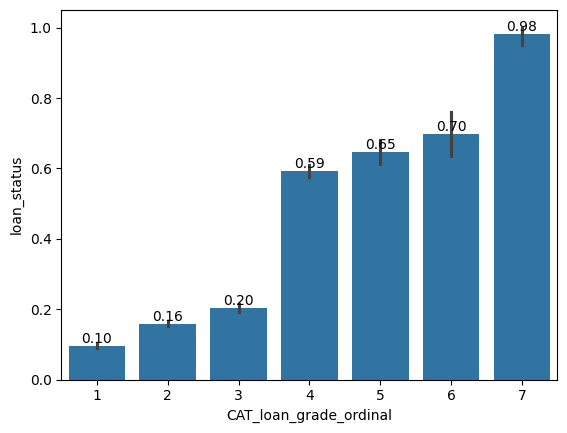

In [ ]:
# percentage of loan default in loan grade

ax = sns.barplot(data=cc_risk_df, x="CAT_loan_grade_ordinal", y="loan_status")
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}')

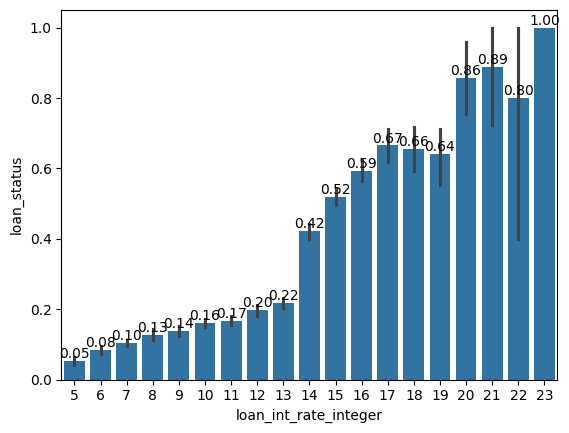

In [ ]:
# percentage of loan defaults in interest rate groups

ax = sns.barplot(data=cc_risk_df, x="loan_int_rate_integer", y="loan_status")
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}')

##### Correlation

In [23]:
cc_risk_df_CAT = cc_risk_df.drop(columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'])
cc_risk_df_CAT.corr()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,CAT_loan_grade_ordinal,CAT_cb_person_default_on_file_binary,CAT_person_home_ownership_nominal,CAT_loan_intent_nominal,loan_int_rate_integer
person_age,1.000000,0.178899,0.165787,0.054172,0.011019,-0.023333,-0.041065,0.859544,0.013515,0.007765,-0.028851,0.036404,0.010104
person_income,0.178899,1.000000,0.136825,0.265879,-0.001381,-0.139938,-0.251511,0.117076,0.001392,-0.002709,-0.126737,0.002541,-0.001877
person_emp_length,0.165787,0.136825,1.000000,0.110759,-0.056405,-0.082638,-0.055167,0.146336,-0.049265,-0.027863,-0.195260,0.021042,-0.056273
loan_amnt,0.054172,0.265879,0.110759,1.000000,0.145904,0.113550,0.577399,0.045294,0.149937,0.040320,-0.078918,-0.003328,0.143551
loan_int_rate,0.011019,-0.001381,-0.056405,0.145904,1.000000,0.339350,0.123500,0.015371,0.933497,0.500254,0.110343,-0.002532,0.996062
loan_status,-0.023333,-0.139938,-0.082638,0.113550,0.339350,1.000000,0.379689,-0.015649,0.379683,0.182019,0.230913,-0.064628,0.339313
loan_percent_income,-0.041065,-0.251511,-0.055167,0.577399,0.123500,0.379689,1.000000,-0.030080,0.125788,0.036170,0.078515,0.000436,0.122366
cb_person_cred_hist_length,0.859544,0.117076,0.146336,0.045294,0.015371,-0.015649,-0.030080,1.000000,0.014570,0.008396,-0.025613,0.035963,0.014558
CAT_loan_grade_ordinal,0.013515,0.001392,-0.049265,0.149937,0.933497,0.379683,0.125788,0.014570,1.000000,0.535833,0.099039,-0.004529,0.933033
CAT_cb_person_default_on_file_binary,0.007765,-0.002709,-0.027863,0.040320,0.500254,0.182019,0.036170,0.008396,0.535833,1.000000,0.048308,-0.002444,0.501294


``NOTE:``
loan_int_rate and loan_grade are highly correlated (but loan grade has slightly higher correlation with other variables)



The variables with the best predictive power for "loan_status" are:
* loan_int_rate (or loan_int_rate_integer) -> ~0.3393
* CAT_loan_grade_ordinal -> 0.3797
* loan_percent_income -> 0.3797
* person_income -> -0.1399
* loan_amnt -> 0.1135
* CAT_loan_grade_ordinal -> 0.3797
* CAT_person_home_ownership_nominal -> 0.2309
* CAT_cb_person_default_on_file_binary -> .1820

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(cc_risk_df["CAT_loan_grade_ordinal"], cc_risk_df["loan_status"])
print(f"r = {r:.4f} | p-value = {p:.4e}")

r = 0.3797 | p-value = 0.0000000000e+00


#### Check and drop nulls

In [14]:
cc_risk_df_CAT.isnull().sum()

person_age                              0
person_income                           0
person_emp_length                       0
loan_amnt                               0
loan_int_rate                           0
loan_status                             0
loan_percent_income                     0
cb_person_cred_hist_length              0
CAT_loan_grade_ordinal                  0
CAT_cb_person_default_on_file_binary    0
CAT_person_home_ownership_nominal       0
CAT_loan_intent_nominal                 0
loan_int_rate_integer                   0
dtype: int64

#### Random Forest

In [19]:
X = cc_risk_df_CAT.drop(columns=['loan_status'])
print(X.shape)
y = cc_risk_df_CAT['loan_status']
print(y.shape)

(28638, 12)
(28638,)


In [20]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

##### RF mean sqr error & R^2

MSE       : 0.0576
Mean R²   : 0.6581
Std  R²   : 0.0204

=== Top 15 Feature Importances ===
loan_percent_income                     0.239047
CAT_loan_grade_ordinal                  0.164880
CAT_person_home_ownership_nominal       0.145387
person_income                           0.121091
CAT_loan_intent_nominal                 0.091431
person_emp_length                       0.057827
loan_int_rate                           0.057318
loan_amnt                               0.041998
person_age                              0.037989
cb_person_cred_hist_length              0.028952
loan_int_rate_integer                   0.009554
CAT_cb_person_default_on_file_binary    0.004526


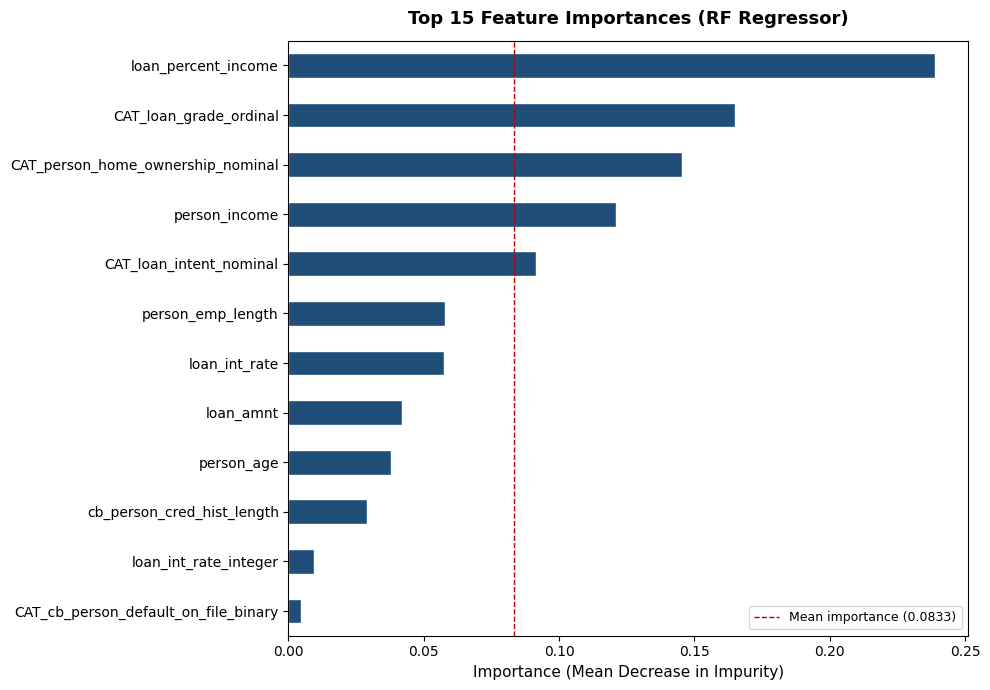

0.05760832824094282
0.658076822821571
0.02043170156481869
loan_percent_income                     0.239047
CAT_loan_grade_ordinal                  0.164880
CAT_person_home_ownership_nominal       0.145387
person_income                           0.121091
CAT_loan_intent_nominal                 0.091431
person_emp_length                       0.057827
loan_int_rate                           0.057318
loan_amnt                               0.041998
person_age                              0.037989
cb_person_cred_hist_length              0.028952
loan_int_rate_integer                   0.009554
CAT_cb_person_default_on_file_binary    0.004526
dtype: float64


In [21]:
def run_random_forest_regressor(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1,
                                top_n=15,
                                plot_importance=True,
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    # MSE
    neg_mse_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=cv, n_jobs=n_jobs
    )

    # R²
    r2_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='r2',
        cv=cv, n_jobs=n_jobs
    )

    # Feature importance — requires a full fit on all training data
    rf_model.fit(X_train, y_train)
    importances = (pd.Series(rf_model.feature_importances_, index=X_train.columns)
                     .sort_values(ascending=False))

    results = {
        "mean_cv_mse":  -np.mean(neg_mse_scores),
        "mean_r2":       np.mean(r2_scores),
        "std_r2":        np.std(r2_scores),
        "importances":   importances,
        "fitted_model":  rf_model,
    }

    print(f"MSE       : {results['mean_cv_mse']:.4f}")
    print(f"Mean R²   : {results['mean_r2']:.4f}")
    print(f"Std  R²   : {results['std_r2']:.4f}")
    print(f"\n=== Top {top_n} Feature Importances ===")
    print(importances.head(top_n).to_string())

    if plot_importance:
        fig, ax = plt.subplots(figsize=(10, 7))
        importances.head(top_n).sort_values().plot(
            kind="barh", ax=ax, color="#1F4E79", edgecolor="white"
        )
        ax.set_title(f"Top {top_n} Feature Importances (RF Regressor)",
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Importance (Mean Decrease in Impurity)", fontsize=11)
        ax.axvline(x=importances.mean(), color="#C00000", linestyle="--",
                   linewidth=1, label=f"Mean importance ({importances.mean():.4f})")
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    return results


# --- Example usage ---
results = run_random_forest_regressor(X_train, y_train,
                                      n_estimators=100,
                                      max_depth=None,
                                      min_samples_split=2,
                                      min_samples_leaf=1,
                                      max_samples=None,
                                      max_leaf_nodes=None,
                                      max_features=1.0,
                                      ccp_alpha=0.0,
                                      top_n=15,
                                      plot_importance=True)

# Access individually
print(results["mean_cv_mse"])
print(results["mean_r2"])
print(results["std_r2"])
print(results["importances"])       # full sorted series
fitted_model = results["fitted_model"]  # fitted model for further use

In [ ]:
cc_risk_df_CAT['loan_status'].describe()

count   28,638.0000
mean         0.2166
std          0.4119
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: loan_status, dtype: float64

##### RF Random & Grid Search

In [ ]:
'''# --- Stage 1: Randomized Search (broad exploration) ---
param_dist = {
    "n_estimators":      randint(50, 500),
    "max_depth":         [3, 5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      uniform(0.1, 0.9),  # 10% to 100% of features
    "max_samples":       uniform(0.5, 0.5),  # 50% to 100% of samples
}

rf_model = RandomForestRegressor(random_state=random_state, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,           # number of random combinations to try
    scoring="r2",
    cv=5,
    random_state=random_state,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f"Best R²     : {random_search.best_score_:.4f}")
print(f"Best Params : {random_search.best_params_}")


# --- Stage 2: Grid Search (zoom in around best params) ---
# Use best params from Stage 1 to build a narrow grid
best = random_search.best_params_

param_grid = {
    "n_estimators":      [best["n_estimators"] - 50,
                          best["n_estimators"],
                          best["n_estimators"] + 50],
    "max_depth":         [best["max_depth"] - 2 if best["max_depth"] else 15,
                          best["max_depth"],
                          best["max_depth"] + 2 if best["max_depth"] else None],
    "min_samples_split": [max(2, best["min_samples_split"] - 2),
                          best["min_samples_split"],
                          best["min_samples_split"] + 2],
    "min_samples_leaf":  [max(1, best["min_samples_leaf"] - 1),
                          best["min_samples_leaf"],
                          best["min_samples_leaf"] + 1],
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"Best R²     : {grid_search.best_score_:.4f}")
print(f"Best Params : {grid_search.best_params_}")


# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print(f"\nTest R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred):.4f}")'''

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best R²     : 0.6598
Best Params : {'max_depth': None, 'max_features': np.float64(0.6805930258275084), 'max_samples': np.float64(0.8344620298315498), 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 366}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best R²     : 0.6601
Best Params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 316}

Test R²  : 0.6743
Test MSE : 0.0567


#### PCA

Components to explain 90% variance: 5

=== Explained Variance per Component ===
    Explained Variance Cumulative Variance
PC1             0.2856              0.2856
PC2             0.2333              0.5189
PC3             0.1657              0.6845
PC4             0.1397              0.8243
PC5             0.1215              0.9457

=== Top 3 Variable Loadings per Component ===

PC1:
  person_age                          +0.6524
  cb_person_cred_hist_length          +0.6396
  person_income                       +0.2764

PC2:
  loan_percent_income                 +0.6790
  loan_amnt                           +0.6723
  loan_int_rate                       +0.2848

PC3:
  person_income                       +0.7192
  person_emp_length                   +0.4130
  cb_person_cred_hist_length          -0.3028

PC4:
  loan_int_rate                       +0.7933
  person_emp_length                   -0.4326
  person_income                       +0.3295

PC5:
  person_emp_length              

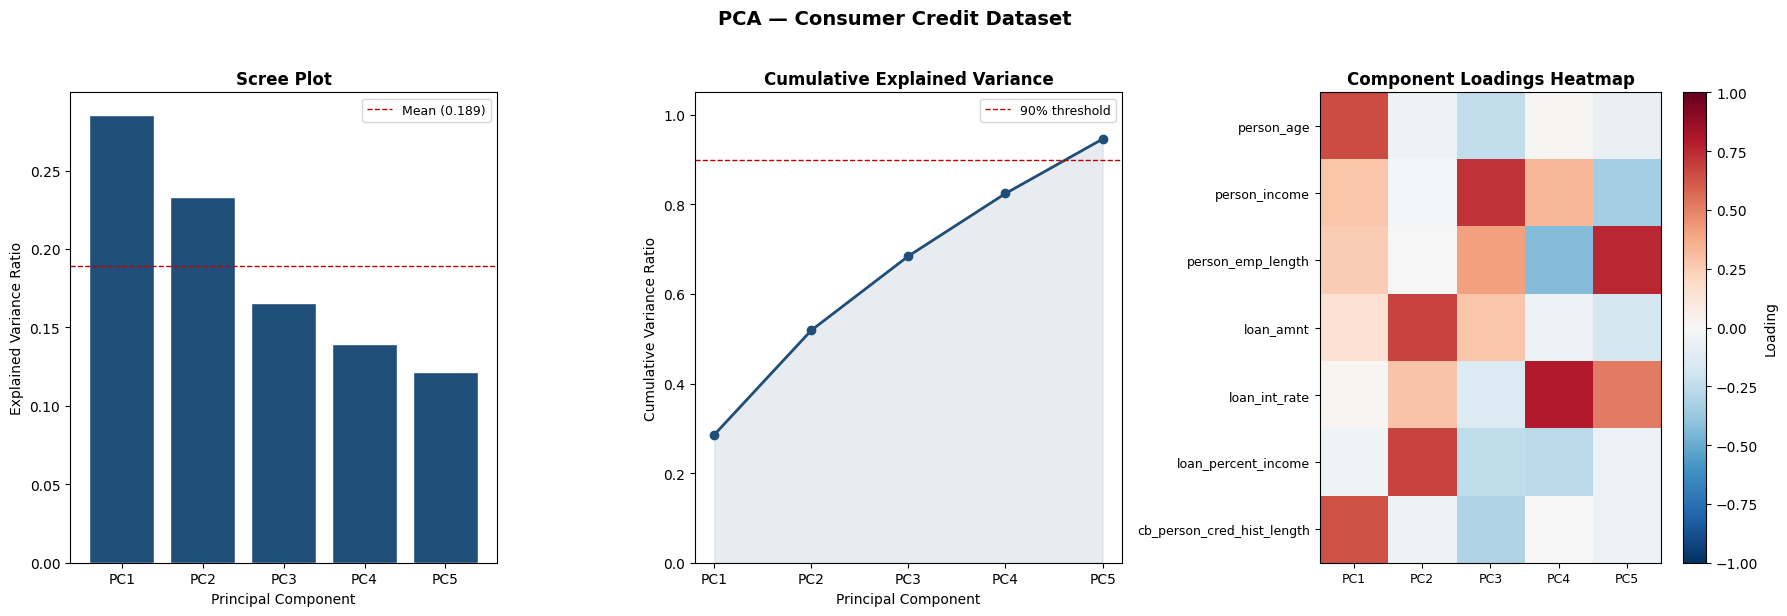

PC1 driven most by: person_age (+0.6524)
PC2 driven most by: loan_percent_income (+0.6790)
PC3 driven most by: person_income (+0.7192)
PC4 driven most by: loan_int_rate (+0.7933)
PC5 driven most by: person_emp_length (+0.7558)


In [ ]:
def run_pca(df: pd.DataFrame,
            numeric_cols: list,
            n_components: int = None,
            variance_threshold: float = 0.90,
            random_state: int = 42):
    """
    Run PCA on the consumer credit dataset and return
    interpretable outputs: explained variance, loadings,
    and transformed components.

    Parameters
    ----------
    df                 : Consumer credit DataFrame
    numeric_cols       : List of numeric columns to include in PCA
                         (exclude target variable and categorical columns)
    n_components       : Number of components to extract.
                         If None, determined by variance_threshold
    variance_threshold : Cumulative variance to explain. Default: 0.90
    random_state       : Random state. Default: 42

    Returns
    -------
    dict with keys:
        pca             - fitted PCA object
        scaler          - fitted StandardScaler object
        explained_var   - explained variance ratio per component
        cumulative_var  - cumulative explained variance
        loadings        - component loadings DataFrame (variables x components)
        df_pca          - original df with PC scores appended
    """

    # --- 1. Scale features (critical before PCA) ---
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(df[numeric_cols])

    # --- 2. Fit PCA ---
    # First fit with all components to determine cutoff
    pca_full  = PCA(random_state=random_state)
    pca_full.fit(X_scaled)

    if n_components is None:
        # Find number of components needed to hit variance_threshold
        cumvar       = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = int(np.argmax(cumvar >= variance_threshold) + 1)
        print(f"Components to explain {variance_threshold*100:.0f}% variance: {n_components}")

    # Refit with selected number of components
    pca      = PCA(n_components=n_components, random_state=random_state)
    X_pca    = pca.fit_transform(X_scaled)

    # --- 3. Explained variance ---
    explained_var  = pd.Series(
        pca.explained_variance_ratio_,
        index=[f"PC{i+1}" for i in range(n_components)],
        name="Explained Variance"
    )
    cumulative_var = explained_var.cumsum().rename("Cumulative Variance")

    # --- 4. Loadings (how much each variable contributes to each PC) ---
    loadings = pd.DataFrame(
        pca.components_.T,
        index=numeric_cols,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    # --- 5. Append PC scores to original df ---
    df_pca = df.copy()
    for i in range(n_components):
        df_pca[f"PC{i+1}"] = X_pca[:, i]

    # --- 6. Print summary ---
    print("\n=== Explained Variance per Component ===")
    summary = pd.concat([explained_var, cumulative_var], axis=1)
    summary["Explained Variance"]  = summary["Explained Variance"].map("{:.4f}".format)
    summary["Cumulative Variance"] = summary["Cumulative Variance"].map("{:.4f}".format)
    print(summary.to_string())

    print("\n=== Top 3 Variable Loadings per Component ===")
    for pc in loadings.columns:
        top3 = loadings[pc].abs().sort_values(ascending=False).head(3)
        print(f"\n{pc}:")
        for var in top3.index:
            print(f"  {var:<35} {loadings.loc[var, pc]:+.4f}")

    return {
        "pca":           pca,
        "scaler":        scaler,
        "explained_var": explained_var,
        "cumulative_var":cumulative_var,
        "loadings":      loadings,
        "df_pca":        df_pca,
    }


def plot_pca(results: dict, top_n_vars: int = 6):
    """
    Plot scree plot, cumulative variance, and component loadings heatmap.

    Parameters
    ----------
    results   : Output dictionary from run_pca()
    top_n_vars: Number of top variables to show per component. Default: 6
    """
    explained_var  = results["explained_var"]
    cumulative_var = results["cumulative_var"]
    loadings       = results["loadings"]
    n_components   = len(explained_var)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- Plot 1: Scree plot ---
    ax = axes[0]
    ax.bar(explained_var.index, explained_var.values, color="#1F4E79", edgecolor="white")
    ax.set_title("Scree Plot", fontsize=12, fontweight="bold")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance Ratio")
    ax.axhline(y=explained_var.mean(), color="#C00000", linestyle="--",
               linewidth=1, label=f"Mean ({explained_var.mean():.3f})")
    ax.legend(fontsize=9)

    # --- Plot 2: Cumulative variance ---
    ax = axes[1]
    ax.plot(cumulative_var.index, cumulative_var.values,
            color="#1F4E79", marker="o", linewidth=2)
    ax.axhline(y=0.90, color="#C00000", linestyle="--",
               linewidth=1, label="90% threshold")
    ax.fill_between(cumulative_var.index, cumulative_var.values,
                    alpha=0.1, color="#1F4E79")
    ax.set_title("Cumulative Explained Variance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Cumulative Variance Ratio")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

    # --- Plot 3: Loadings heatmap ---
    ax = axes[2]
    im = ax.imshow(loadings.values, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(range(n_components))
    ax.set_xticklabels(loadings.columns, fontsize=9)
    ax.set_yticks(range(len(loadings.index)))
    ax.set_yticklabels(loadings.index, fontsize=9)
    ax.set_title("Component Loadings Heatmap", fontsize=12, fontweight="bold")
    plt.colorbar(im, ax=ax, label="Loading")

    plt.suptitle("PCA — Consumer Credit Dataset", fontsize=14,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# --- Example usage ---

# Define your numeric features (exclude target and categoricals)
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",   # loan to income ratio
    "cb_person_cred_hist_length",
]

# Run PCA
results = run_pca(
    df           = cc_risk_df_CAT,
    numeric_cols = numeric_cols,
    variance_threshold = 0.90,
)

# Plot
plot_pca(results)

# --- Access outputs ---
loadings   = results["loadings"]    # variable contributions per component
df_pca     = results["df_pca"]      # original df with PC1, PC2... appended
explained  = results["explained_var"]

# Most important variable per component
for pc in loadings.columns:
    top_var = loadings[pc].abs().idxmax()
    print(f"{pc} driven most by: {top_var} ({loadings.loc[top_var, pc]:+.4f})")

### FRED ... again

#### EDA pre-processing

##### Add group and subgroups

In [629]:
# create yield curve variable

macro_fred_df["10y_3m_yield_curve_slope"] = (macro_fred_df["T10YFFM"] - macro_fred_df["TB3MS"])

In [630]:
# Group and Subgroup mappings for FRED-MD variables
GROUPS = {
    "sasdate":           "Date",
    "RPI":               "Output & Income",
    "W875RX1":           "Output & Income",
    "DPCERA3M086SBEA":   "Output & Income",
    "CMRMTSPLx":         "Output & Income",
    "RETAILx":           "Output & Income",
    "INDPRO":            "Output & Income",
    "IPFPNSS":           "Output & Income",
    "IPFINAL":           "Output & Income",
    "IPCONGD":           "Output & Income",
    "IPDCONGD":          "Output & Income",
    "IPNCONGD":          "Output & Income",
    "IPBUSEQ":           "Output & Income",
    "IPMAT":             "Output & Income",
    "IPDMAT":            "Output & Income",
    "IPNMAT":            "Output & Income",
    "IPMANSICS":         "Output & Income",
    "IPB51222S":         "Output & Income",
    "IPFUELS":           "Output & Income",
    "CUMFNS":            "Output & Income",
    "HWI":               "Labor Market",
    "HWIURATIO":         "Labor Market",
    "CLF16OV":           "Labor Market",
    "CE16OV":            "Labor Market",
    "UNRATE":            "Labor Market",
    "UEMPMEAN":          "Labor Market",
    "UEMPLT5":           "Labor Market",
    "UEMP5TO14":         "Labor Market",
    "UEMP15OV":          "Labor Market",
    "UEMP15T26":         "Labor Market",
    "UEMP27OV":          "Labor Market",
    "CLAIMSx":           "Labor Market",
    "PAYEMS":            "Labor Market",
    "USGOOD":            "Labor Market",
    "CES1021000001":     "Labor Market",
    "USCONS":            "Labor Market",
    "MANEMP":            "Labor Market",
    "DMANEMP":           "Labor Market",
    "NDMANEMP":          "Labor Market",
    "SRVPRD":            "Labor Market",
    "USTPU":             "Labor Market",
    "USWTRADE":          "Labor Market",
    "USTRADE":           "Labor Market",
    "USFIRE":            "Labor Market",
    "USGOVT":            "Labor Market",
    "CES0600000007":     "Labor Market",
    "AWOTMAN":           "Labor Market",
    "AWHMAN":            "Labor Market",
    "CES0600000008":     "Labor Market",
    "CES2000000008":     "Labor Market",
    "CES3000000008":     "Labor Market",
    "HOUST":             "Housing",
    "HOUSTNE":           "Housing",
    "HOUSTMW":           "Housing",
    "HOUSTS":            "Housing",
    "HOUSTW":            "Housing",
    "PERMIT":            "Housing",
    "PERMITNE":          "Housing",
    "PERMITMW":          "Housing",
    "PERMITS":           "Housing",
    "PERMITW":           "Housing",
    "ACOGNO":            "Consumption, Orders & Inventories",
    "AMDMNOx":           "Consumption, Orders & Inventories",
    "ANDENOx":           "Consumption, Orders & Inventories",
    "AMDMUOx":           "Consumption, Orders & Inventories",
    "BUSINVx":           "Consumption, Orders & Inventories",
    "ISRATIOx":          "Consumption, Orders & Inventories",
    "UMCSENTx":          "Consumption, Orders & Inventories",
    "M1SL":              "Money & Credit",
    "M2SL":              "Money & Credit",
    "M2REAL":            "Money & Credit",
    "BOGMBASE":          "Money & Credit",
    "TOTRESNS":          "Money & Credit",
    "NONBORRES":         "Money & Credit",
    "BUSLOANS":          "Money & Credit",
    "REALLN":            "Money & Credit",
    "NONREVSL":          "Money & Credit",
    "CONSPI":            "Money & Credit",
    "DTCOLNVHFNM":       "Money & Credit",
    "DTCTHFNM":          "Money & Credit",
    "INVEST":            "Money & Credit",
    "10y_3m_yield_curve_slope": "Interest & Exchange Rates",
    "FEDFUNDS":          "Interest & Exchange Rates",
    "CP3Mx":             "Interest & Exchange Rates",
    "TB3MS":             "Interest & Exchange Rates",
    "TB6MS":             "Interest & Exchange Rates",
    "GS1":               "Interest & Exchange Rates",
    "GS5":               "Interest & Exchange Rates",
    "GS10":              "Interest & Exchange Rates",
    "AAA":               "Interest & Exchange Rates",
    "BAA":               "Interest & Exchange Rates",
    "COMPAPFFx":         "Interest & Exchange Rates",
    "TB3SMFFM":          "Interest & Exchange Rates",
    "TB6SMFFM":          "Interest & Exchange Rates",
    "T1YFFM":            "Interest & Exchange Rates",
    "T5YFFM":            "Interest & Exchange Rates",
    "T10YFFM":           "Interest & Exchange Rates",
    "AAAFFM":            "Interest & Exchange Rates",
    "BAAFFM":            "Interest & Exchange Rates",
    "TWEXAFEGSMTHx":     "Interest & Exchange Rates",
    "EXSZUSx":           "Interest & Exchange Rates",
    "EXJPUSx":           "Interest & Exchange Rates",
    "EXUSUKx":           "Interest & Exchange Rates",
    "EXCAUSx":           "Interest & Exchange Rates",
    "WPSFD49207":        "Prices",
    "WPSFD49502":        "Prices",
    "WPSID61":           "Prices",
    "WPSID62":           "Prices",
    "OILPRICEx":         "Prices",
    "PPICMM":            "Prices",
    "CPIAUCSL":          "Prices",
    "CPIAPPSL":          "Prices",
    "CPITRNSL":          "Prices",
    "CPIMEDSL":          "Prices",
    "CUSR0000SAC":       "Prices",
    "CUSR0000SAD":       "Prices",
    "CUSR0000SAS":       "Prices",
    "CPIULFSL":          "Prices",
    "CUSR0000SA0L2":     "Prices",
    "CUSR0000SA0L5":     "Prices",
    "PCEPI":             "Prices",
    "DDURRG3M086SBEA":   "Prices",
    "DNDGRG3M086SBEA":   "Prices",
    "DSERRG3M086SBEA":   "Prices",
    "S&P 500":           "Stock Market",
    "S&P div yield":     "Stock Market",
    "S&P PE ratio":      "Stock Market",
    "VIXCLSx":           "Stock Market",
}

SUBGROUPS = {
    "sasdate":           "N/A",
    "RPI":               "Aggregate",
    "W875RX1":           "Aggregate",
    "DPCERA3M086SBEA":   "Aggregate",
    "CMRMTSPLx":         "Aggregate",
    "RETAILx":           "Aggregate",
    "INDPRO":            "Aggregate",
    "IPFPNSS":           "IP: Products",
    "IPFINAL":           "IP: Products",
    "IPCONGD":           "IP: Consumer Goods",
    "IPDCONGD":          "IP: Consumer Goods",
    "IPNCONGD":          "IP: Consumer Goods",
    "IPBUSEQ":           "IP: Business Equipment",
    "IPMAT":             "IP: Materials",
    "IPDMAT":            "IP: Materials",
    "IPNMAT":            "IP: Materials",
    "IPMANSICS":         "IP: Manufacturing",
    "IPB51222S":         "IP: Utilities & Fuels",
    "IPFUELS":           "IP: Utilities & Fuels",
    "CUMFNS":            "Aggregate",
    "HWI":               "Aggregate",
    "HWIURATIO":         "Aggregate",
    "CLF16OV":           "Aggregate",
    "CE16OV":            "Aggregate",
    "UNRATE":            "Unemployment",
    "UEMPMEAN":          "Unemployment",
    "UEMPLT5":           "Unemployment: Duration",
    "UEMP5TO14":         "Unemployment: Duration",
    "UEMP15OV":          "Unemployment: Duration",
    "UEMP15T26":         "Unemployment: Duration",
    "UEMP27OV":          "Unemployment: Duration",
    "CLAIMSx":           "Aggregate",
    "PAYEMS":            "Payrolls: Aggregate",
    "USGOOD":            "Payrolls: Sector",
    "CES1021000001":     "Payrolls: Sector",
    "USCONS":            "Payrolls: Sector",
    "MANEMP":            "Payrolls: Sector",
    "DMANEMP":           "Payrolls: Sector",
    "NDMANEMP":          "Payrolls: Sector",
    "SRVPRD":            "Payrolls: Sector",
    "USTPU":             "Payrolls: Sector",
    "USWTRADE":          "Payrolls: Sector",
    "USTRADE":           "Payrolls: Sector",
    "USFIRE":            "Payrolls: Sector",
    "USGOVT":            "Payrolls: Sector",
    "CES0600000007":     "Hours & Earnings",
    "AWOTMAN":           "Hours & Earnings",
    "AWHMAN":            "Hours & Earnings",
    "CES0600000008":     "Hours & Earnings",
    "CES2000000008":     "Hours & Earnings",
    "CES3000000008":     "Hours & Earnings",
    "HOUST":             "Housing Starts: Aggregate",
    "HOUSTNE":           "Housing Starts: Regional",
    "HOUSTMW":           "Housing Starts: Regional",
    "HOUSTS":            "Housing Starts: Regional",
    "HOUSTW":            "Housing Starts: Regional",
    "PERMIT":            "Building Permits: Aggregate",
    "PERMITNE":          "Building Permits: Regional",
    "PERMITMW":          "Building Permits: Regional",
    "PERMITS":           "Building Permits: Regional",
    "PERMITW":           "Building Permits: Regional",
    "ACOGNO":            "New Orders",
    "AMDMNOx":           "New Orders",
    "ANDENOx":           "New Orders",
    "AMDMUOx":           "Unfilled Orders",
    "BUSINVx":           "Inventories",
    "ISRATIOx":          "Inventories",
    "UMCSENTx":          "Consumer Sentiment",
    "M1SL":              "Money Supply",
    "M2SL":              "Money Supply",
    "M2REAL":            "Money Supply",
    "BOGMBASE":          "Money Supply",
    "TOTRESNS":          "Bank Reserves",
    "NONBORRES":         "Bank Reserves",
    "BUSLOANS":          "Loans & Credit",
    "REALLN":            "Loans & Credit",
    "NONREVSL":          "Loans & Credit",
    "CONSPI":            "Loans & Credit",
    "DTCOLNVHFNM":       "Loans & Credit",
    "DTCTHFNM":          "Loans & Credit",
    "INVEST":            "Loans & Credit",
    "FEDFUNDS":          "Policy Rate",
    "CP3Mx":             "Short-Term Rates",
    "TB3MS":             "Short-Term Rates",
    "TB6MS":             "Short-Term Rates",
    "GS1":               "Treasury Yields",
    "GS5":               "Treasury Yields",
    "GS10":              "Treasury Yields",
    "AAA":               "Corporate Bond Yields",
    "BAA":               "Corporate Bond Yields",
    "COMPAPFFx":         "Spreads",
    "TB3SMFFM":          "Spreads",
    "TB6SMFFM":          "Spreads",
    "T1YFFM":            "Spreads",
    "T5YFFM":            "Spreads",
    "T10YFFM":           "Spreads",
    "AAAFFM":            "Spreads",
    "BAAFFM":            "Spreads",
    "10y_3m_yield_curve_slope": "Spreads",
    "TWEXAFEGSMTHx":     "Exchange Rates",
    "EXSZUSx":           "Exchange Rates",
    "EXJPUSx":           "Exchange Rates",
    "EXUSUKx":           "Exchange Rates",
    "EXCAUSx":           "Exchange Rates",
    "WPSFD49207":        "PPI",
    "WPSFD49502":        "PPI",
    "WPSID61":           "PPI",
    "WPSID62":           "PPI",
    "OILPRICEx":         "Commodity Prices",
    "PPICMM":            "PPI",
    "CPIAUCSL":          "CPI: Aggregate",
    "CPIAPPSL":          "CPI: Category",
    "CPITRNSL":          "CPI: Category",
    "CPIMEDSL":          "CPI: Category",
    "CUSR0000SAC":       "CPI: Category",
    "CUSR0000SAD":       "CPI: Category",
    "CUSR0000SAS":       "CPI: Category",
    "CPIULFSL":          "CPI: Ex-Food & Energy",
    "CUSR0000SA0L2":     "CPI: Ex-Food & Energy",
    "CUSR0000SA0L5":     "CPI: Ex-Food & Energy",
    "PCEPI":             "PCE",
    "DDURRG3M086SBEA":   "PCE",
    "DNDGRG3M086SBEA":   "PCE",
    "DSERRG3M086SBEA":   "PCE",
    "S&P 500":           "Equity Index",
    "S&P div yield":     "Equity Valuation",
    "S&P PE ratio":      "Equity Valuation",
    "VIXCLSx":           "Volatility",
}


In [631]:
# Group and Subgroup function

def append_group_subgroup(df: pd.DataFrame, date_col: str = "sasdate") -> pd.DataFrame:
    """
    Append Group and Subgroup columns to a FRED-MD DataFrame.
    Works on both raw and transformed versions of the dataset.

    Parameters
    ----------
    df       : FRED-MD DataFrame (rows = months, columns = variables)
    date_col : Name of the date column. Default: 'sasdate'

    Returns
    -------
    pd.DataFrame in long format with columns:
        sasdate, variable, value, group, subgroup

    Example
    -------
        raw = pd.read_csv("current.csv")
        raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

        df_long = append_group_subgroup(raw)
        print(df_long.head())

        # Filter to a specific group for EDA
        housing = df_long[df_long["group"] == "Housing"]
        labor   = df_long[df_long["group"] == "Labor Market"]

        # Filter to aggregate-only variables to reduce dataset
        aggregates = df_long[df_long["subgroup"].str.contains("Aggregate")]
    """
    # Melt wide → long so each row is one variable-month observation
    df_long = df.melt(id_vars=date_col, var_name="variable", value_name="value")

    # Map group and subgroup
    df_long["group"]    = df_long["variable"].map(GROUPS)
    df_long["subgroup"] = df_long["variable"].map(SUBGROUPS)

    # Flag any unmapped variables
    unmapped = df_long[df_long["group"].isna()]["variable"].unique()
    if len(unmapped) > 0:
        print(f"[Warning] {len(unmapped)} unmapped variable(s): {list(unmapped)}")

    return df_long


# --- Example usage ---
import pandas as pd

#raw = pd.read_csv("../2026-02-MD_edited.csv")
raw = macro_fred_df
raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

df_long = append_group_subgroup(raw)
print(df_long.head(10))
print(f"\nShape: {df_long.shape}")
print(f"\nGroups:\n{df_long['group'].value_counts()}")
print(f"\nSample subgroups:\n{df_long['subgroup'].value_counts().head(15)}")

# --- EDA-ready filters ---
housing      = df_long[df_long["group"] == "Housing"]
labor        = df_long[df_long["group"] == "Labor Market"]
prices       = df_long[df_long["group"] == "Prices"]
aggregates   = df_long[df_long["subgroup"].str.contains("Aggregate", na=False)]
regional     = df_long[df_long["subgroup"].str.contains("Regional", na=False)]

     sasdate variable   value            group   subgroup
0   5/1/1959      RPI -0.1162  Output & Income  Aggregate
1   6/1/1959      RPI -0.6361  Output & Income  Aggregate
2   7/1/1959      RPI     NaN  Output & Income  Aggregate
3   8/1/1959      RPI     NaN  Output & Income  Aggregate
4   9/1/1959      RPI     NaN  Output & Income  Aggregate
5  10/1/1959      RPI  0.5100  Output & Income  Aggregate
6  11/1/1959      RPI  1.7827  Output & Income  Aggregate
7  12/1/1959      RPI  0.2988  Output & Income  Aggregate
8   1/1/1960      RPI -1.1504  Output & Income  Aggregate
9   2/1/1960      RPI -1.0337  Output & Income  Aggregate

Shape: (101727, 5)

Groups:
group
Labor Market                         24831
Interest & Exchange Rates            18423
Prices                               16020
Output & Income                      15219
Money & Credit                       10413
Housing                               8010
Consumption, Orders & Inventories     5607
Stock Market              

In [632]:
macro_fred_df.shape

(801, 128)

##### df_long filter dataset

`NOTE:` df_long dataframe is a small dataset with **ONLY** the names of groups and subgroups appended. I can use it to filter for EDA purposes. 

In [633]:
df_long

,sasdate,variable,value,group,subgroup
0,5/1/1959,RPI,-0.1162,Output & Income,Aggregate
1,6/1/1959,RPI,-0.6361,Output & Income,Aggregate
2,7/1/1959,RPI,NaN,Output & Income,Aggregate
3,8/1/1959,RPI,NaN,Output & Income,Aggregate
4,9/1/1959,RPI,NaN,Output & Income,Aggregate
...,...,...,...,...,...
101722,9/1/2025,10y_3m_yield_curve_slope,-0.0400,Interest & Exchange Rates,Spreads
101723,10/1/2025,10y_3m_yield_curve_slope,-0.1200,Interest & Exchange Rates,Spreads
101724,11/1/2025,10y_3m_yield_curve_slope,0.1500,Interest & Exchange Rates,Spreads
101725,12/1/2025,10y_3m_yield_curve_slope,0.5600,Interest & Exchange Rates,Spreads


##### Filter function

In [634]:
def filter_fredmd(
    df_transformed: pd.DataFrame,
    df_long: pd.DataFrame,
    group: str,
    subgroup: str = None,
    date_col: str = "sasdate",
    target: str = None,
    printout: bool = True
) -> pd.DataFrame:
    """
    Filter the transformed FRED-MD DataFrame by group and optionally subgroup.
    Uses df_long only as a lookup map to identify variable names,
    then extracts those columns from df_transformed.

    Optionally computes correlation of all group variables against a target
    variable, even if the target belongs to a different group.

    Parameters
    ----------
    df_transformed : Wide transformed FRED-MD DataFrame (output of transform_fredmd())
    df_long        : Long-format FRED-MD DataFrame (output of append_group_subgroup())
                     Used only as a variable name map
    group          : Group name to filter on
    subgroup       : Optional subgroup to filter on
    date_col       : Name of the date column. Default: 'sasdate'
    target         : Optional target variable for correlation. Can be from
                     any group — does not need to belong to the filtered group.
                     If provided, returns a sorted correlation Series instead
                     of the filtered DataFrame.

    Returns
    -------
    If target is None:
        pd.DataFrame — subset of df_transformed columns matching the group/subgroup
    If target is provided:
        pd.DataFrame — single-column correlation table sorted descending,
                       with absolute correlation column for easy ranking

    Examples
    --------
        # Filtered DataFrame, no correlation
        housing = filter_fredmd(df_transformed, df_long, group="Housing")

        # Correlate all Labor Market variables against CONSPI (Money & Credit)
        corr = filter_fredmd(df_transformed, df_long,
                             group="Labor Market",
                             target="CONSPI")

        # Correlate Housing Starts subgroup against FEDFUNDS
        corr = filter_fredmd(df_transformed, df_long,
                             group="Housing",
                             subgroup="Housing Starts: Aggregate",
                             target="FEDFUNDS")
    """
    # --- Validate group ---
    available_groups = df_long["group"].dropna().unique()
    if group not in available_groups:
        raise ValueError(
            f"'{group}' not found. Available groups:\n  " +
            "\n  ".join(sorted(available_groups))
        )

    mask = df_long["group"] == group

    # --- Optionally filter subgroup ---
    if subgroup is not None:
        available_subgroups = df_long.loc[mask, "subgroup"].dropna().unique()
        if subgroup not in available_subgroups:
            raise ValueError(
                f"'{subgroup}' not found in group '{group}'. "
                f"Available subgroups:\n  " +
                "\n  ".join(sorted(available_subgroups))
            )
        mask = mask & (df_long["subgroup"] == subgroup)

    # --- Get variable names from df_long, extract from df_transformed ---
    variables = df_long.loc[mask, "variable"].unique().tolist()
    cols      = [date_col] + [v for v in variables if v in df_transformed.columns]

    # --- Warn if any mapped variables are missing from df_transformed ---
    missing = [v for v in variables if v not in df_transformed.columns]
    if missing:
        print(f"[Warning] {len(missing)} variable(s) in map but not in df_transformed: {missing}")

    result = df_transformed[cols].copy()

    # --- Summary ---
    label = f"{group} > {subgroup}" if subgroup else group
    print(f"Filter    : {label}")
    print(f"Variables : {len(cols) - 1} | Months : {len(result)}")
    print(f"Columns   : {[c for c in cols if c != date_col]}\n")

    # --- Optional correlation against target ---
    if target is not None:

        # Validate target exists in df_transformed
        if target not in df_transformed.columns:
            raise ValueError(
                f"Target '{target}' not found in df_transformed. "
                f"Check the variable name."
            )

        # Pull target from df_transformed directly (even if outside group)
        target_series = df_transformed[target]

        # Warn if target is already inside the filtered group
        if target in result.columns:
            print(f"[Note] '{target}' is already in the filtered group — "
                  f"it will be excluded from the correlation output.\n")

        # Compute correlations of each group variable against target
        group_vars = [c for c in result.columns if c != date_col]
        corr_vals  = {var: result[var].corr(target_series) for var in group_vars}

        corr_df = (
            pd.DataFrame.from_dict(corr_vals, orient="index", columns=[f"corr_with_{target}"])
            .assign(abs_corr=lambda x: x[f"corr_with_{target}"].abs())
            .sort_values("abs_corr", ascending=False)
            .drop(columns="abs_corr")
        )

        # Drop only the self-correlation (target vs itself = always 1.0)
        corr_df = corr_df[corr_df.index != target]

        # Tag each variable with its subgroup for context
        var_meta = (df_long[["variable", "subgroup"]]
                    .drop_duplicates()
                    .set_index("variable"))
        corr_df  = corr_df.join(var_meta, how="left")

        target_group = df_long.loc[df_long["variable"] == target, "group"].values
        target_group = target_group[0] if len(target_group) > 0 else "Unknown"
        if printout == True:
            print(f"Target    : {target} (Group: {target_group})")
            print(f"Sorted by absolute correlation ↓\n")
            print(corr_df.to_string())

        return corr_df

    return result


# --- Example usage ---

# Correlate all Labor Market variables against CONSPI (from Money & Credit)
corr = filter_fredmd(macro_fred_df, df_long,
                     group="Output & Income",
                     target="CONSPI")

# Correlate Housing subgroup against FEDFUNDS (from Interest & Exchange Rates)
corr = filter_fredmd(macro_fred_df, df_long,
                     group="Interest & Exchange Rates",
                     subgroup="Spreads",
                     target="10y_3m_yield_curve_slope")

Filter    : Output & Income
Variables : 19 | Months : 801
Columns   : ['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS']

Target    : CONSPI (Group: Money & Credit)
Sorted by absolute correlation ↓

                 corr_with_CONSPI                subgroup
RPI                       -0.3509               Aggregate
W875RX1                   -0.1658               Aggregate
CMRMTSPLx                 -0.1474               Aggregate
CUMFNS                    -0.0930               Aggregate
INDPRO                    -0.0908               Aggregate
IPDMAT                    -0.0745           IP: Materials
IPMANSICS                 -0.0706       IP: Manufacturing
IPMAT                     -0.0678           IP: Materials
IPBUSEQ                   -0.0507  IP: Business Equipment
RETAILx                   -0.0432               Aggregat

/home/codespace/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


#### EDA

##### Filter groups corr

In [635]:
target_var = 'RPI'

inventory = filter_fredmd(macro_fred_df, df_long,
                     group="Consumption, Orders & Inventories",
                     target=target_var,
                     printout=False)

housing = filter_fredmd(macro_fred_df, df_long,
                     group="Housing",
                     target=target_var,
                     printout=False)

rates = filter_fredmd(macro_fred_df, df_long,
                     group="Interest & Exchange Rates",
                     target=target_var,
                     printout=False)

labor = filter_fredmd(macro_fred_df, df_long,
                     group="Labor Market",
                     target=target_var,
                     printout=False)

credit = filter_fredmd(macro_fred_df, df_long,
                     group="Money & Credit",
                     target=target_var,
                     printout=False)

income = filter_fredmd(macro_fred_df, df_long,
                     group="Output & Income",
                     target=target_var,
                     printout=False)
            
prices = filter_fredmd(macro_fred_df, df_long,
                     group="Prices",
                     target=target_var,
                     printout=False)

stocks = filter_fredmd(macro_fred_df, df_long,
                     group="Stock Market",
                     target=target_var,
                     printout=False)

Filter    : Consumption, Orders & Inventories
Variables : 7 | Months : 801
Columns   : ['ACOGNO', 'AMDMNOx', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'ISRATIOx', 'UMCSENTx']

Filter    : Housing
Variables : 10 | Months : 801
Columns   : ['HOUST', 'HOUSTNE', 'HOUSTMW', 'HOUSTS', 'HOUSTW', 'PERMIT', 'PERMITNE', 'PERMITMW', 'PERMITS', 'PERMITW']

Filter    : Interest & Exchange Rates
Variables : 23 | Months : 801
Columns   : ['FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'COMPAPFFx', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'TWEXAFEGSMTHx', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', '10y_3m_yield_curve_slope']



/home/codespace/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


Filter    : Labor Market
Variables : 31 | Months : 801
Columns   : ['HWI', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UNRATE', 'UEMPMEAN', 'UEMPLT5', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'UEMP27OV', 'CLAIMSx', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'SRVPRD', 'USTPU', 'USWTRADE', 'USTRADE', 'USFIRE', 'USGOVT', 'CES0600000007', 'AWOTMAN', 'AWHMAN', 'CES0600000008', 'CES2000000008', 'CES3000000008']

Filter    : Money & Credit
Variables : 13 | Months : 801
Columns   : ['M1SL', 'M2SL', 'M2REAL', 'BOGMBASE', 'TOTRESNS', 'NONBORRES', 'BUSLOANS', 'REALLN', 'NONREVSL', 'CONSPI', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST']



/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
/home/codespace/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/codespace/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/codespace/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2887: RuntimeWarning: invalid 

Filter    : Output & Income
Variables : 19 | Months : 801
Columns   : ['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS']

[Note] 'RPI' is already in the filtered group — it will be excluded from the correlation output.

Filter    : Prices
Variables : 20 | Months : 801
Columns   : ['WPSFD49207', 'WPSFD49502', 'WPSID61', 'WPSID62', 'OILPRICEx', 'PPICMM', 'CPIAUCSL', 'CPIAPPSL', 'CPITRNSL', 'CPIMEDSL', 'CUSR0000SAC', 'CUSR0000SAD', 'CUSR0000SAS', 'CPIULFSL', 'CUSR0000SA0L2', 'CUSR0000SA0L5', 'PCEPI', 'DDURRG3M086SBEA', 'DNDGRG3M086SBEA', 'DSERRG3M086SBEA']

Filter    : Stock Market
Variables : 4 | Months : 801
Columns   : ['S&P 500', 'S&P div yield', 'S&P PE ratio', 'VIXCLSx']



In [636]:
group = [inventory, housing, rates, labor, credit, income, prices, stocks]
#group = [inventory, housing, labor, credit, income, prices, stocks]

number_of_var = 5

groups = []
temp_list = []

for g in group:
    print(g.head(number_of_var))
    g = g.reset_index(drop=False)
    temp_list = g['index'].head(number_of_var).values.tolist()
    groups.extend(temp_list)

          corr_with_RPI            subgroup
ANDENOx          0.1485          New Orders
UMCSENTx        -0.0727  Consumer Sentiment
AMDMUOx         -0.0555     Unfilled Orders
ACOGNO           0.0550          New Orders
ISRATIOx        -0.0541         Inventories
          corr_with_RPI                     subgroup
HOUSTS          -0.0610     Housing Starts: Regional
PERMITNE        -0.0590   Building Permits: Regional
PERMIT          -0.0583  Building Permits: Aggregate
HOUST           -0.0526    Housing Starts: Aggregate
HOUSTW          -0.0525     Housing Starts: Regional
         corr_with_RPI          subgroup
CP3Mx          -0.1857  Short-Term Rates
GS1            -0.1717   Treasury Yields
TB6MS          -0.1524  Short-Term Rates
TB3MS          -0.1391  Short-Term Rates
EXUSUKx        -0.1258    Exchange Rates
               corr_with_RPI                subgroup
CES0600000008        -0.7010        Hours & Earnings
UEMP15OV              0.1740  Unemployment: Duration
CE16OV       

##### Check nulls

In [637]:
null_summary = pd.DataFrame({
    "null_count": macro_fred_df[groups].isnull().sum(),
    "null_pct":   (macro_fred_df[groups].isnull().mean() * 100).round(2)
}).sort_values("null_count", ascending=False)

null_summary = null_summary[null_summary["null_count"] > 0]
print(null_summary)

                 null_count  null_pct
CES0600000008           792   98.8800
CES3000000008           791   98.7500
CPIMEDSL                787   98.2500
CUSR0000SAS             783   97.7500
CPIAPPSL                782   97.6300
DSERRG3M086SBEA         771   96.2500
PCEPI                   748   93.3800
BUSLOANS                740   92.3800
M2SL                    734   91.6400
DTCOLNVHFNM             707   88.2600
ACOGNO                  665   83.0200
ANDENOx                 656   81.9000
UEMP15OV                590   73.6600
EXUSUKx                 558   69.6600
S&P PE ratio            528   65.9200
S&P 500                 469   58.5500
INDPRO                  432   53.9300
IPDMAT                  420   52.4300
RETAILx                 409   51.0600
CE16OV                  391   48.8100
AMDMUOx                 362   45.1900
M2REAL                  342   42.7000
W875RX1                 299   37.3300
UMCSENTx                226   28.2100
VIXCLSx                  38    4.7400
PERMITNE    

##### build X and y; drop nulls

In [638]:
target_var = 'RPI'

# Columns to drop due to high null percentage
drop_cols = ['ACOGNO','HOUSTNE','HOUSTMW','PERMITMW', 'UMCSENTx','AAAFFM',"T10YFFM", "T5YFFM", "T1YFFM", "TB6SMFFM", "TB3SMFFM","CONSPI","NONREVSL"]

drop_nulls_df = macro_fred_df.copy()

print(f"Before: {drop_nulls_df.shape}")

# Drop rows with VIX and target nulls
drop_nulls_df = drop_nulls_df.dropna(subset=["VIXCLSx", target_var])

# Set X
X = drop_nulls_df[groups]

# Drop high null columns if they exist in X
cols_to_drop = [c for c in drop_cols if c in X.columns]
if cols_to_drop:
    X = X.drop(columns=cols_to_drop)
    print(f"Dropped: {cols_to_drop}")

# Set y
y = drop_nulls_df[target_var]

print(X.shape)

Before: (801, 128)
Dropped: ['ACOGNO', 'UMCSENTx', 'CONSPI']
(498, 36)


In [639]:
X

,ANDENOx,AMDMUOx,ISRATIOx,HOUSTS,PERMITNE,PERMIT,HOUST,HOUSTW,CP3Mx,GS1,TB6MS,TB3MS,EXUSUKx,CES0600000008,UEMP15OV,CE16OV,CES3000000008,HWI,BUSLOANS,M2SL,DTCOLNVHFNM,M2REAL,W875RX1,CUMFNS,RETAILx,IPDMAT,INDPRO,CUSR0000SAS,CPIMEDSL,PCEPI,CPIAPPSL,DSERRG3M086SBEA,VIXCLSx,S&P PE ratio,S&P div yield,S&P 500
38,NaN,NaN,-0.0207,1.8332,1.6902,1.9574,1.9850,1.7835,0.0200,0.2600,0.2600,0.1500,NaN,NaN,NaN,NaN,NaN,56.0000,NaN,NaN,NaN,-0.4391,1.3458,0.9527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.5715,NaN,-0.4571,NaN
39,NaN,NaN,-0.0103,1.8389,1.6918,1.9587,1.9912,1.7895,-0.1700,-0.3500,-0.3700,-0.2900,NaN,NaN,NaN,NaN,NaN,-24.0000,NaN,NaN,NaN,-0.0713,-1.4441,-0.6061,-0.9305,-0.5193,-2.2034,NaN,NaN,NaN,NaN,NaN,15.7942,0.4557,-0.0093,0.1203
40,NaN,NaN,0.0207,1.8166,1.6869,1.9614,1.9725,1.7835,0.1000,-0.0500,0.0300,0.0600,NaN,NaN,-0.7796,-0.7778,NaN,-3.0000,NaN,NaN,NaN,-0.9911,0.0614,0.4299,-0.7311,0.2805,1.7893,NaN,NaN,NaN,NaN,NaN,18.3148,NaN,0.1280,NaN
41,NaN,0.5123,-0.0103,1.8632,1.7020,1.9564,1.9927,1.7772,-0.1100,0.0600,-0.0300,0.0000,NaN,NaN,NaN,NaN,NaN,3.0000,-5.6574,2.4674,NaN,1.7337,1.0230,-0.7731,1.6530,-0.9870,-1.7967,NaN,NaN,NaN,NaN,NaN,25.9671,NaN,0.1033,NaN
42,NaN,NaN,-0.0207,1.8505,1.7027,1.9629,2.0003,1.8069,0.0300,0.1000,0.1400,0.1300,0.4053,NaN,NaN,NaN,NaN,29.0000,NaN,-0.3314,NaN,-0.0757,0.3645,0.8565,-1.0962,0.8417,1.3846,NaN,NaN,NaN,NaN,NaN,16.7658,NaN,-0.3594,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,NaN,-1.9509,-0.0200,1.9035,1.5607,1.9854,1.9888,1.7936,0.1400,0.0600,0.0800,0.0700,NaN,NaN,NaN,NaN,NaN,-536.0000,NaN,NaN,NaN,NaN,NaN,1.2203,NaN,NaN,NaN,NaN,NaN,0.3493,NaN,NaN,17.0705,NaN,-0.0189,NaN
790,NaN,2.9900,0.0000,1.8788,1.5643,1.9879,1.9757,1.7339,-0.0600,-0.1400,-0.1300,-0.0300,0.6576,NaN,NaN,NaN,NaN,2.0000,NaN,0.8971,NaN,1.1704,NaN,-0.6283,3.5906,-1.1810,NaN,NaN,NaN,NaN,NaN,NaN,21.6579,NaN,0.0910,NaN
791,NaN,NaN,0.0100,1.8893,1.5918,1.9824,1.9800,1.6989,0.0800,0.0200,0.0400,0.0300,-0.4972,NaN,2.3085,0.8202,NaN,475.0000,NaN,4.3429,NaN,0.4496,-2.9192,-0.4185,NaN,-0.1978,NaN,NaN,NaN,NaN,NaN,NaN,32.5116,NaN,0.0000,NaN
795,NaN,2.9900,0.0100,1.8720,1.5677,1.9731,1.9690,1.7446,-0.0300,-0.2100,-0.1800,-0.1500,NaN,NaN,NaN,NaN,NaN,168.0000,NaN,NaN,NaN,NaN,NaN,-0.3395,-0.1727,1.0952,NaN,NaN,NaN,NaN,NaN,-4.0489,15.7545,-1.7740,0.0325,-0.8935


In [640]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

In [641]:
print(f"NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"NaNs in y_train: {y_train.isna().sum()}")
print(f"NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"NaNs in y_test:  {y_test.isna().sum()}")

NaNs in X_train: 5466
NaNs in y_train: 0
NaNs in X_test:  2393
NaNs in y_test:  0


In [642]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

ANDENOx            275
AMDMUOx            145
EXUSUKx            239
CES0600000008      344
UEMP15OV           267
CE16OV             140
CES3000000008      341
BUSLOANS           330
M2SL               317
DTCOLNVHFNM        311
M2REAL             133
W875RX1             42
RETAILx            166
IPDMAT             150
INDPRO             154
CUSR0000SAS        342
CPIMEDSL           344
PCEPI              328
CPIAPPSL           335
DSERRG3M086SBEA    337
S&P PE ratio       228
S&P 500            198
dtype: int64


#### Random Forest

In [643]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

random_state = 42

##### RF mean squared error & R^2

MSE       : 0.7236
Mean R²   : 0.3573
Std  R²   : 0.0776

=== Top 15 Feature Importances (MDI) ===
W875RX1         0.5096
UEMP15OV        0.0374
S&P PE ratio    0.0294
INDPRO          0.0292
EXUSUKx         0.0258
IPDMAT          0.0246
HOUSTS          0.0214
RETAILx         0.0201
S&P div yield   0.0200
CE16OV          0.0187
CUMFNS          0.0187
AMDMUOx         0.0186
PERMIT          0.0174
VIXCLSx         0.0171
HWI             0.0169

=== Top 15 Mutual Information Scores ===
W875RX1         0.6833
M2REAL          0.0843
S&P div yield   0.0637
VIXCLSx         0.0566
TB6MS           0.0392
HWI             0.0349
IPDMAT          0.0331
HOUSTW          0.0317
CUMFNS          0.0223
INDPRO          0.0151
CP3Mx           0.0146
HOUSTS          0.0140
PERMIT          0.0135
UEMP15OV        0.0119
CPIAPPSL        0.0097

=== VIF Scores (>5 = moderate, >10 = high multicollinearity) ===
                        VIF
feature                    
PERMIT          34,716.3930
HOUST           34,

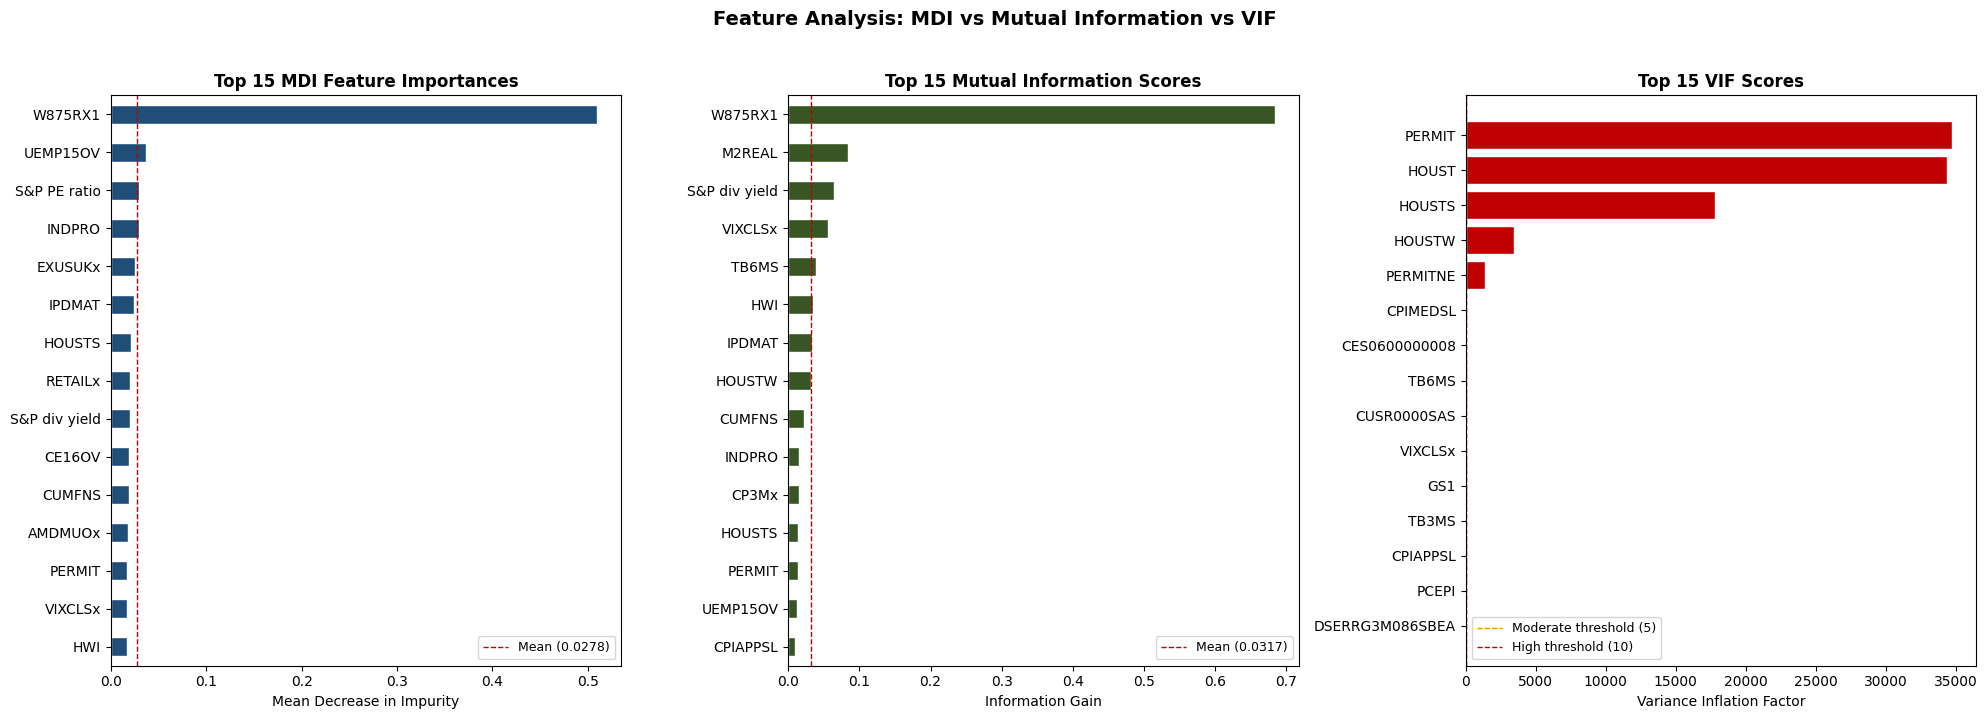

0.723577219949874
0.3573062113161088
0.07761988356970938
W875RX1           0.5096
UEMP15OV          0.0374
S&P PE ratio      0.0294
INDPRO            0.0292
EXUSUKx           0.0258
IPDMAT            0.0246
HOUSTS            0.0214
RETAILx           0.0201
S&P div yield     0.0200
CE16OV            0.0187
CUMFNS            0.0187
AMDMUOx           0.0186
PERMIT            0.0174
VIXCLSx           0.0171
HWI               0.0169
PERMITNE          0.0168
HOUSTW            0.0131
GS1               0.0129
M2SL              0.0124
CPIAPPSL          0.0123
M2REAL            0.0122
HOUST             0.0118
CP3Mx             0.0118
TB6MS             0.0116
ISRATIOx          0.0113
BUSLOANS          0.0107
S&P 500           0.0099
TB3MS             0.0097
CES0600000008     0.0053
ANDENOx           0.0049
PCEPI             0.0044
DSERRG3M086SBEA   0.0027
DTCOLNVHFNM       0.0012
CES3000000008     0.0003
CUSR0000SAS       0.0000
CPIMEDSL          0.0000
dtype: float64
W875RX1           0.6833
M2R

In [644]:
def run_random_forest_regressor(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1,
                                top_n=15,
                                plot_importance=True,
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    # --- MSE ---
    neg_mse_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=cv, n_jobs=n_jobs
    )

    # --- R² ---
    r2_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='r2',
        cv=cv, n_jobs=n_jobs
    )

    # --- Feature Importance (MDI) ---
    rf_model.fit(X_train, y_train)
    importances = (pd.Series(rf_model.feature_importances_, index=X_train.columns)
                     .sort_values(ascending=False))

    from sklearn.impute import SimpleImputer

    imputer     = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    mi_scores = mutual_info_regression(X_train_imp, y_train, random_state=random_state)
    mi_series = (pd.Series(mi_scores, index=X_train_imp.columns)
                .sort_values(ascending=False))

    # --- VIF ---
    vif_data = pd.DataFrame({
        "feature": X_train_imp.columns,
        "VIF":     [variance_inflation_factor(X_train_imp.values, i)
                    for i in range(X_train_imp.shape[1])]
    }).set_index("feature").sort_values("VIF", ascending=False)

    # --- Comparison Table (MDI rank vs MI rank vs VIF) ---
    comparison = pd.DataFrame({
        "MDI Importance":     importances,
        "MDI Rank":           importances.rank(ascending=False).astype(int),
        "Mutual Information": mi_series,
        "MI Rank":            mi_series.rank(ascending=False).astype(int),
        "VIF":                vif_data["VIF"],
    }).sort_values("MDI Importance", ascending=False)

    results = {
        "mean_cv_mse":  -np.mean(neg_mse_scores),
        "mean_r2":       np.mean(r2_scores),
        "std_r2":        np.std(r2_scores),
        "importances":   importances,
        "mi_scores":     mi_series,
        "vif":           vif_data,
        "comparison":    comparison,
        "fitted_model":  rf_model,
    }

    # --- Print Summary ---
    print(f"MSE       : {results['mean_cv_mse']:.4f}")
    print(f"Mean R²   : {results['mean_r2']:.4f}")
    print(f"Std  R²   : {results['std_r2']:.4f}")

    print(f"\n=== Top {top_n} Feature Importances (MDI) ===")
    print(importances.head(top_n).to_string())

    print(f"\n=== Top {top_n} Mutual Information Scores ===")
    print(mi_series.head(top_n).to_string())

    print(f"\n=== VIF Scores (>5 = moderate, >10 = high multicollinearity) ===")
    print(vif_data.to_string())

    print(f"\n=== Feature Ranking Comparison (sorted by MDI) ===")
    print(comparison.head(top_n).to_string())

    # --- Plots ---
    if plot_importance:
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))

        # Plot 1: MDI Feature Importance
        importances.head(top_n).sort_values().plot(
            kind="barh", ax=axes[0], color="#1F4E79", edgecolor="white"
        )
        axes[0].set_title(f"Top {top_n} MDI Feature Importances",
                          fontsize=12, fontweight="bold")
        axes[0].set_xlabel("Mean Decrease in Impurity")
        axes[0].axvline(x=importances.mean(), color="#C00000", linestyle="--",
                        linewidth=1, label=f"Mean ({importances.mean():.4f})")
        axes[0].legend(fontsize=9)

        # Plot 2: Mutual Information
        mi_series.head(top_n).sort_values().plot(
            kind="barh", ax=axes[1], color="#375623", edgecolor="white"
        )
        axes[1].set_title(f"Top {top_n} Mutual Information Scores",
                          fontsize=12, fontweight="bold")
        axes[1].set_xlabel("Information Gain")
        axes[1].axvline(x=mi_series.mean(), color="#C00000", linestyle="--",
                        linewidth=1, label=f"Mean ({mi_series.mean():.4f})")
        axes[1].legend(fontsize=9)

        # Plot 3: VIF
        vif_plot = vif_data.head(top_n).sort_values("VIF")
        colors    = ["#C00000" if v > 10 else "#FF8C00" if v > 5
                     else "#1F4E79" for v in vif_plot["VIF"]]
        axes[2].barh(vif_plot.index, vif_plot["VIF"],
                     color=colors, edgecolor="white")
        axes[2].set_title(f"Top {top_n} VIF Scores",
                          fontsize=12, fontweight="bold")
        axes[2].set_xlabel("Variance Inflation Factor")
        axes[2].axvline(x=5,  color="#FF8C00", linestyle="--",
                        linewidth=1, label="Moderate threshold (5)")
        axes[2].axvline(x=10, color="#C00000", linestyle="--",
                        linewidth=1, label="High threshold (10)")
        axes[2].legend(fontsize=9)

        plt.suptitle("Feature Analysis: MDI vs Mutual Information vs VIF",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    return results


# --- Example usage ---
results = run_random_forest_regressor(X_train, y_train,
                                      n_estimators=100,
                                      max_depth=None,
                                      min_samples_split=2,
                                      min_samples_leaf=1,
                                      max_samples=None,
                                      max_leaf_nodes=None,
                                      max_features=1.0,
                                      ccp_alpha=0.0,
                                      top_n=15,
                                      plot_importance=True)

# Access individually
print(results["mean_cv_mse"])
print(results["mean_r2"])
print(results["std_r2"])
print(results["importances"])    # MDI sorted series
print(results["mi_scores"])      # Mutual information sorted series
print(results["vif"])            # VIF table
print(results["comparison"])     # Side by side ranking table
fitted_model = results["fitted_model"]

##### RF w VIF prune

Dropping 'PERMIT' (VIF=34716.39)
Dropping 'HOUST' (VIF=21094.75)


Dropping 'HOUSTS' (VIF=3066.70)
Dropping 'HOUSTW' (VIF=1002.93)
Dropping 'PERMITNE' (VIF=134.66)
Dropping 'CPIMEDSL' (VIF=45.67)
Dropping 'CES0600000008' (VIF=21.00)
Dropping 'TB6MS' (VIF=18.71)

Done. All VIFs below 10.0.

Total dropped : 8
Dropped vars  : ['PERMIT', 'HOUST', 'HOUSTS', 'HOUSTW', 'PERMITNE', 'CPIMEDSL', 'CES0600000008', 'TB6MS']
Remaining     : 28 features

Final VIF scores:
CUSR0000SAS       8.6586
VIXCLSx           7.4571
CPIAPPSL          4.5326
PCEPI             3.8490
GS1               3.5096
TB3MS             3.1986
DSERRG3M086SBEA   2.9452
CP3Mx             2.7733
CUMFNS            1.4912
S&P div yield     1.3708
S&P 500           1.3663
ISRATIOx          1.2867
INDPRO            1.2829
IPDMAT            1.2592
S&P PE ratio      1.2559
M2SL              1.2030
ANDENOx           1.1723
M2REAL            1.1676
UEMP15OV          1.1616
RETAILx           1.1599
W875RX1           1.1570
AMDMUOx           1.1407
DTCOLNVHFNM       1.1157
HWI               1.1073
CE16O

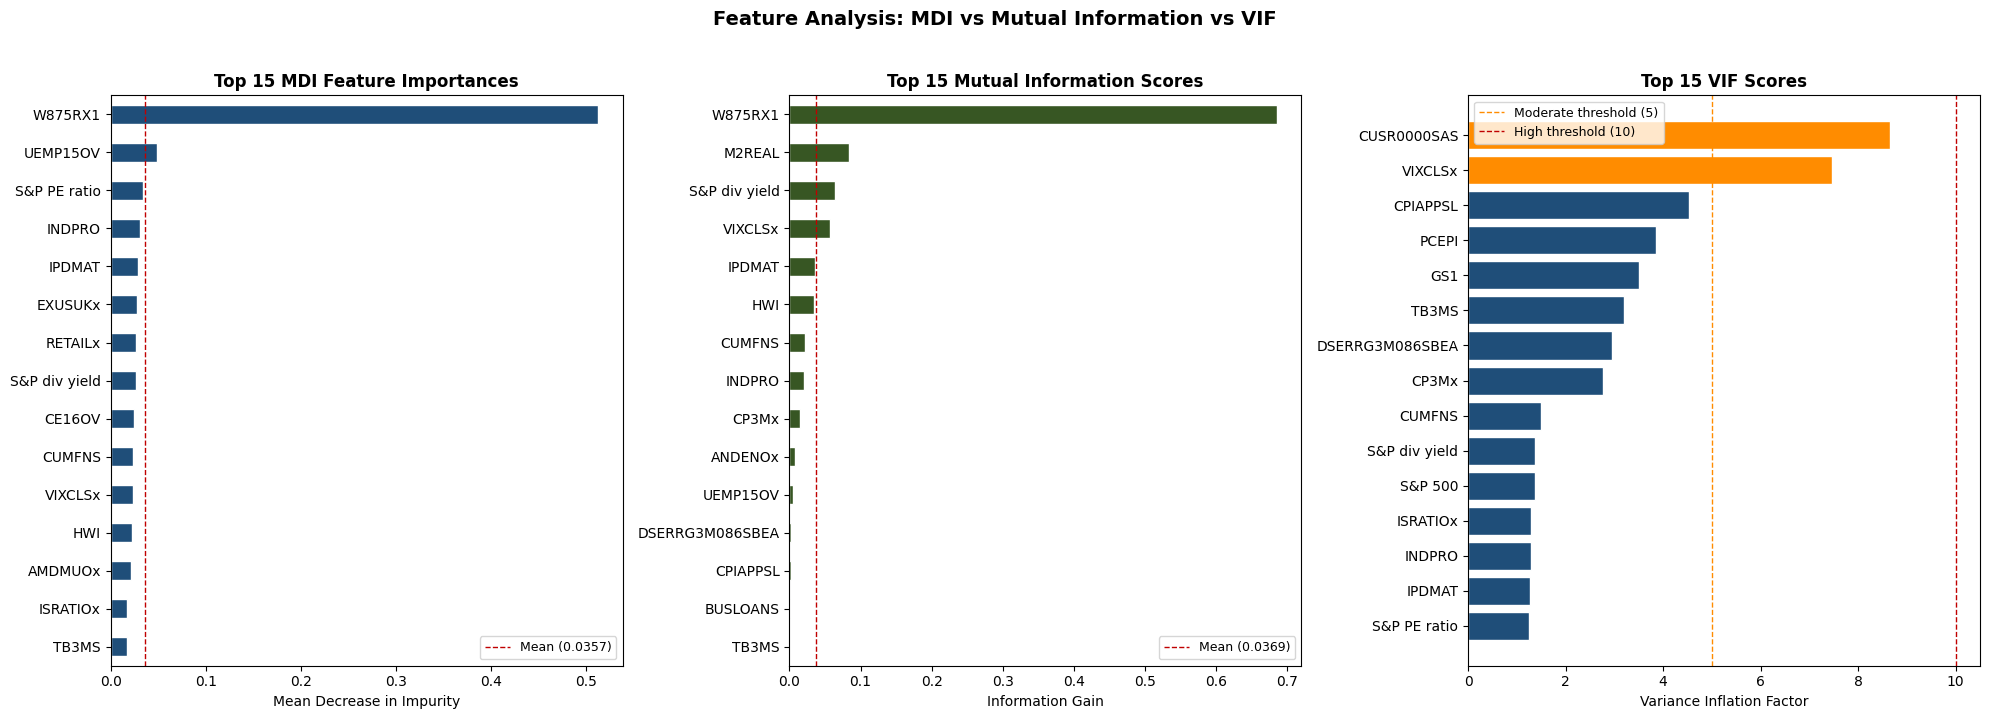

In [645]:
def prune_by_vif(X: pd.DataFrame, threshold: float = 10.0) -> pd.DataFrame:
    """
    Iteratively remove the highest VIF feature until all VIFs
    are below the threshold. Returns pruned DataFrame.
    """
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from sklearn.impute import SimpleImputer
    import numpy as np

    X_pruned = X.copy()
    dropped  = []

    while True:
        imp   = SimpleImputer(strategy="median")
        X_imp = pd.DataFrame(imp.fit_transform(X_pruned),
                             columns=X_pruned.columns)

        vifs = pd.Series(
            [variance_inflation_factor(X_imp.values, i)
             for i in range(X_imp.shape[1])],
            index=X_pruned.columns
        )

        max_vif = vifs.max()
        max_var = vifs.idxmax()

        if max_vif <= threshold:
            print(f"\nDone. All VIFs below {threshold}.")
            break

        print(f"Dropping '{max_var}' (VIF={max_vif:.2f})")
        dropped.append(max_var)
        X_pruned = X_pruned.drop(columns=max_var)

    print(f"\nTotal dropped : {len(dropped)}")
    print(f"Dropped vars  : {dropped}")
    print(f"Remaining     : {X_pruned.shape[1]} features")
    print(f"\nFinal VIF scores:\n{vifs[vifs.index.isin(X_pruned.columns)].sort_values(ascending=False).to_string()}")

    return X_pruned


# --- Run pruning ---
X_train_pruned = prune_by_vif(X_train, threshold=10.0)

# Align test set to same columns
X_test_pruned  = X_test[X_train_pruned.columns]

# Rerun model on pruned features
results_pruned = run_random_forest_regressor(
    X_train_pruned, y_train,
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    ccp_alpha=0.0,
    top_n=15,
    plot_importance=True
)

In [646]:
def plot_test_results(model, X_test, y_test,
                      target_var: str = "BAAFFM",
                      date_col: pd.Series = None,
                      figsize: tuple = (16, 12)):
    """
    Plot actual vs predicted results on the test set after VIF pruning.

    Parameters
    ----------
    model      : Fitted Random Forest model (results["fitted_model"])
    X_test     : Test features (VIF pruned)
    y_test     : Test target
    target_var : Name of target variable for labels
    date_col   : Optional date series aligned to X_test for x-axis
    figsize    : Figure size
    """

    y_pred     = model.predict(X_test)
    r2         = r2_score(y_test, y_pred)
    mse        = mean_squared_error(y_test, y_pred)
    residuals  = y_test.values - y_pred

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f"Test Set Diagnostics — Target: {target_var}",
                 fontsize=14, fontweight="bold", y=1.01)

    # --- Plot 1: Actual vs Predicted over time ---
    ax = axes[0, 0]
    x_axis = date_col.values if date_col is not None else np.arange(len(y_test))
    ax.plot(x_axis, y_test.values, color="#1F4E79",
            linewidth=1.5, label="Actual")
    ax.plot(x_axis, y_pred, color="#C00000",
            linewidth=1.5, linestyle="--", label="Predicted")
    ax.set_title("Actual vs Predicted Over Time",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Date" if date_col is not None else "Observation")
    ax.set_ylabel(target_var)
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if date_col is not None:
        ax.tick_params(axis="x", rotation=45)

    # --- Plot 2: Actual vs Predicted scatter ---
    ax = axes[0, 1]
    ax.scatter(y_test, y_pred, color="#1F4E79",
               alpha=0.5, edgecolors="white", s=40)
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color="#C00000", linestyle="--",
            linewidth=1.5, label="Perfect Prediction")
    ax.set_title(f"Actual vs Predicted Scatter\nR² = {r2:.4f} | MSE = {mse:.4f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(f"Actual {target_var}")
    ax.set_ylabel(f"Predicted {target_var}")
    ax.legend(fontsize=10)
    ax.grid(linestyle="--", alpha=0.4)

    # --- Plot 3: Residuals over time ---
    ax = axes[1, 0]
    ax.plot(x_axis, residuals, color="#375623",
            linewidth=1, alpha=0.8)
    ax.axhline(y=0, color="#C00000", linestyle="--", linewidth=1.5)
    ax.fill_between(x_axis, residuals, 0,
                    where=(residuals > 0), color="#1F4E79",
                    alpha=0.2, label="Overpredicted")
    ax.fill_between(x_axis, residuals, 0,
                    where=(residuals < 0), color="#C00000",
                    alpha=0.2, label="Underpredicted")
    ax.set_title("Residuals Over Time",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Date" if date_col is not None else "Observation")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if date_col is not None:
        ax.tick_params(axis="x", rotation=45)

    # --- Plot 4: Residual distribution ---
    ax = axes[1, 1]
    ax.hist(residuals, bins=30, color="#1F4E79",
            edgecolor="white", alpha=0.8)
    ax.axvline(x=0, color="#C00000", linestyle="--",
               linewidth=1.5, label="Zero residual")
    ax.axvline(x=residuals.mean(), color="#375623", linestyle="--",
               linewidth=1.5, label=f"Mean residual ({residuals.mean():.4f})")
    ax.set_title("Residual Distribution",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print(f"=== Test Set Performance ===")
    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {np.sqrt(mse):.4f}")
    print(f"Mean Residual  : {residuals.mean():.4f}")
    print(f"Std  Residual  : {residuals.std():.4f}")
    print(f"Max Overshoot  : {residuals.max():.4f}")
    print(f"Max Undershoot : {residuals.min():.4f}")


###### Prune plot

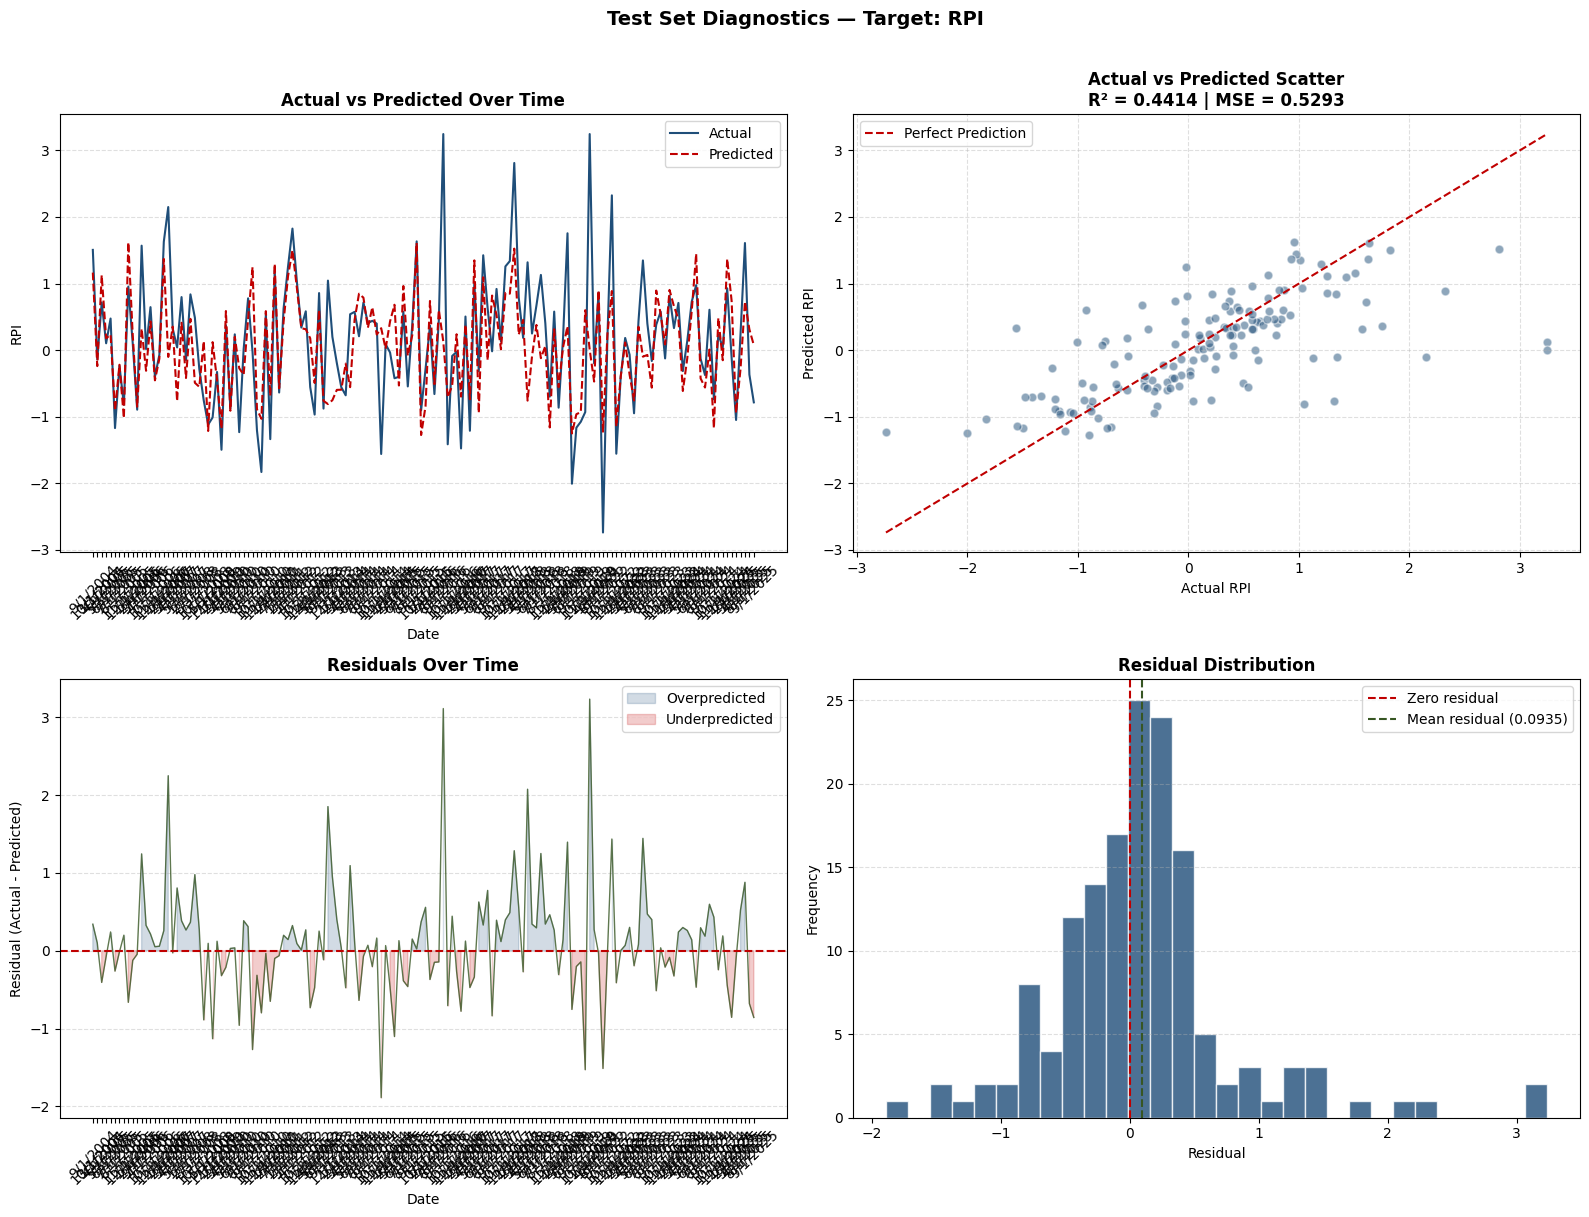

=== Test Set Performance ===
R²   : 0.4414
MSE  : 0.5293
RMSE : 0.7275
Mean Residual  : 0.0935
Std  Residual  : 0.7215
Max Overshoot  : 3.2350
Max Undershoot : -1.8883


In [647]:
# --- Test set dates aligned to X_test_pruned ---
test_dates = drop_nulls_df["sasdate"].iloc[
    -len(y_test):
].reset_index(drop=True)

# --- Plot test results ---
plot_test_results(
    model      = results_pruned["fitted_model"],
    X_test     = X_test_pruned,
    y_test     = y_test,
    target_var = target_var,
    date_col   = test_dates
)

In [648]:
macro_fred_df.isnull().sum()

sasdate                       0
RPI                         275
W875RX1                     299
DPCERA3M086SBEA             350
CMRMTSPLx                   528
                           ... 
DTCOLNVHFNM                 707
DTCTHFNM                    713
INVEST                      749
VIXCLSx                      38
10y_3m_yield_curve_slope      0
Length: 128, dtype: int64

In [649]:
macro_fred_df['BAA'].describe()

count   801.0000
mean     -0.0003
std       0.2192
min      -0.7600
25%      -0.1200
50%       0.0000
75%       0.1100
max       0.6000
Name: BAA, dtype: float64

##### RF w grid search

In [650]:
# --- Stage 1: Randomized Search (broad exploration) ---
param_dist = {
    "n_estimators":      randint(50, 500),
    "max_depth":         [3, 5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      uniform(0.1, 0.9),  # 10% to 100% of features
    "max_samples":       uniform(0.5, 0.5),  # 50% to 100% of samples
}

rf_model = RandomForestRegressor(random_state=random_state, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,           # number of random combinations to try
    scoring="r2",
    cv=5,
    random_state=random_state,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f"Best R²     : {random_search.best_score_:.4f}")
print(f"Best Params : {random_search.best_params_}")


# --- Stage 2: Grid Search (zoom in around best params) ---
# Use best params from Stage 1 to build a narrow grid
best = random_search.best_params_

param_grid = {
    "n_estimators":      [best["n_estimators"] - 50,
                          best["n_estimators"],
                          best["n_estimators"] + 50],
    "max_depth":         [best["max_depth"] - 2 if best["max_depth"] else 15,
                          best["max_depth"],
                          best["max_depth"] + 2 if best["max_depth"] else None],
    "min_samples_split": [max(2, best["min_samples_split"] - 2),
                          best["min_samples_split"],
                          best["min_samples_split"] + 2],
    "min_samples_leaf":  [max(1, best["min_samples_leaf"] - 1),
                          best["min_samples_leaf"],
                          best["min_samples_leaf"] + 1],
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"Best R²     : {grid_search.best_score_:.4f}")
print(f"Best Params : {grid_search.best_params_}")


# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print(f"\nTest R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
# plot_fredmd_dual(macro_fred_df, var1="CONSPI", var2="CONSPI")